# Newscast analysis — deliverable

Newscast side of the project, reusing the segmentation engine (`newscast_segmentation.py`) and the
candidate/party + poll tables in `Project_Features`.

- **Task 2 — single newscast (`Telejornal_RTP_Nov_10`):** what topics the broadcast covered and for how long.
- **All newscasts (multi-video):** the same topic view across every transmission, the same story on both
  channels (RTP vs TVI), candidate mentions vs polls over time, and poll/coverage volatility.

## Setup

In [1]:
import re, glob, math, warnings
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 60); warnings.filterwarnings('ignore')
FEATURES_DIR = 'Project_Features'
SHARED_DAYS = ['Nov_10', 'Nov_20', 'Dec_2', 'Dec_11', 'Dec_18', 'Jan_6']   # days with BOTH RTP and TVI
MATCH_MIN = 0.55
RANDOM_STATE = 42

MONTHS = {'Oct': (2025, 10), 'October': (2025, 10), 'Nov': (2025, 11), 'November': (2025, 11),
          'Dec': (2025, 12), 'December': (2025, 12), 'Jan': (2026, 1), 'January': (2026, 1),
          'Feb': (2026, 2), 'February': (2026, 2)}
def day_to_date(s):
    mon, d = s.split('_'); y, m = MONTHS[mon]; return date(y, m, int(d))

CANDIDATE_ALIASES = {
    'Gouveia_Melo': ['gouveia e melo', 'gouveia melo', 'henrique gouveia', 'almirante gouveia'],
    'Marques_Mendes': ['marques mendes', 'luís marques mendes', 'luis marques mendes', 'marques-mendes'],
    'Seguro': ['antónio josé seguro', 'antonio jose seguro', 'josé seguro', 'jose seguro', 'seguro'],
    'Ventura': ['andré ventura', 'andre ventura', 'ventura'],
    'Cotrim_Figueiredo': ['cotrim figueiredo', 'joão cotrim', 'joao cotrim', 'cotrim'],
    'Filipe': ['antónio filipe', 'antonio filipe'],
    'Martins': ['catarina martins', 'martins'],
    'Pinto': ['jorge pinto', 'pinto'],
}
CANDS = list(CANDIDATE_ALIASES)
def scan_candidates(text):
    low = str(text).lower()
    return {c for c, al in CANDIDATE_ALIASES.items() if any(a in low for a in al)}
print('Setup ready.')

Setup ready.


## Segmentation engine (inlined)

The full pipeline from `newscast_segmentation.py` is pasted here so this notebook runs **standalone** — no external module import. It is exposed below as `ns.*`. (Collapse this cell when reading.)

In [2]:

import math
import re
import warnings
from dataclasses import dataclass
from difflib import SequenceMatcher
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer


VIDEO_EXTENSIONS = (".mp4", ".mov", ".mkv", ".avi", ".m4v")

DEFAULT_WEIGHTS = {
    "semantic_shift": 0.35,
    "ocr_headline_shift": 0.25,
    "ocr_layout_shift": 0.15,
    "face_shift": 0.15,
    "speaker_shift": 0.10,
}

HEADLINE_COLUMNS = [
    "video", "headline", "start_s", "end_s", "duration_s", "observations",
    "mean_conf", "mean_x", "mean_y",
]

PT_STOPWORDS = {
    "a", "ao", "aos", "as", "ate", "com", "como", "da", "das", "de", "do",
    "dos", "e", "em", "entre", "era", "esta", "estao", "foi", "ha", "isso",
    "isto", "mais", "mas", "mesmo", "na", "nas", "no", "nos", "o", "os",
    "ou", "para", "pela", "pelas", "pelo", "pelos", "por", "que", "se",
    "sem", "ser", "sua", "sao", "tambem", "tem", "uma", "um", "vai",
    "ter", "ja", "nao", "hoje", "agora", "sobre", "porque", "quando",
    "onde", "foram", "esta", "este", "esta", "todos", "todo", "toda",
    "num", "numa", "lhe", "lhes", "ele", "ela", "eles", "elas", "nosso",
    "nossa", "seu", "sua", "suas", "seus", "pode", "podem", "tambem",
    "anos", "parte", "caso", "momento", "pessoas", "pessoa",
}

BOILERPLATE_RE = re.compile(
    r"(?i)\b("
    r"rtp|tvi|telejornal|jornal|direto|directo|noticias|noticias|"
    r"seg|ter|qua|qui|sex|sab|sabado|dom|domingo"
    r")\b"
)
TIME_RE = re.compile(r"\b\d{1,2}[:h]\d{2}\b")
DATE_RE = re.compile(r"(?i)\b(seg|ter|qua|qui|sex|sab|s[aá]b|dom)\.?\s*\d{1,2}\b")
TAG_RE = re.compile(r"<[^>]+>")
WORD_RE = re.compile(r"[a-zA-ZÀ-ÿ]+(?:-[a-zA-ZÀ-ÿ]+)?")


@dataclass(frozen=True)
class SegmentationConfig:
    features_dir: str | Path = "Project_Features"
    raw_video_dir: str | Path | None = None
    ocr_conf_threshold: float = 0.60
    headline_similarity_threshold: float = 0.78
    headline_max_gap_s: float = 8.0
    headline_min_observations: int = 2
    headline_min_duration_s: float = 3.0
    semantic_window_segments: int = 3
    boundary_min_gap_s: float = 35.0
    min_item_duration_s: float = 20.0
    snap_window_s: float = 10.0
    face_sample_fps: float = 1.0
    max_topic_clusters: int = 8


def list_newscast_videos(features_dir: str | Path = "Project_Features") -> list[str]:
    features_path = Path(features_dir)
    speech = {p.name.replace("_speech.pkl", "") for p in features_path.glob("Telejornal_*_speech.pkl")}
    ocr = {p.name.replace("_ocr.pkl", "") for p in features_path.glob("Telejornal_*_ocr.pkl")}
    missing_ocr = sorted(speech - ocr)
    missing_speech = sorted(ocr - speech)
    if missing_ocr or missing_speech:
        raise AssertionError(
            "Mismatched Telejornal speech/OCR files. "
            f"Missing OCR: {missing_ocr}; missing speech: {missing_speech}"
        )
    return sorted(speech)


def parse_embedding(value) -> np.ndarray | None:
    if value is None:
        return None
    if isinstance(value, np.ndarray):
        return value.astype(float, copy=False)
    if isinstance(value, (list, tuple)):
        return np.nan_to_num(np.asarray(value, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return None
    if "..." in text:
        return None
    text = text.strip("[]")
    arr = np.fromstring(text.replace(",", " "), sep=" ")
    if arr.size == 0:
        return None
    return np.nan_to_num(arr.astype(float, copy=False), nan=0.0, posinf=0.0, neginf=0.0)


def _timestamp_col(df: pd.DataFrame) -> str:
    for col in ("timestamp", "time stamp", "time_stamp", "start", "start_s"):
        if col in df.columns:
            return col
    raise KeyError(f"No timestamp-like column found. Columns: {list(df.columns)}")


def load_speech(features_dir: str | Path, videos: Iterable[str]) -> pd.DataFrame:
    rows = []
    features_path = Path(features_dir)
    for video in videos:
        df = pd.read_pickle(features_path / f"{video}_speech.pkl").copy()
        df["video"] = video
        ts_col = _timestamp_col(df)
        df["start_s"] = pd.to_numeric(df[ts_col], errors="coerce")
        df["duration"] = pd.to_numeric(df["duration"], errors="coerce").fillna(0.0)
        df["end_s"] = df["start_s"] + df["duration"]
        df["transcript"] = df.get("transcript", "").fillna("").astype(str)
        embed_cols = [c for c in df.columns if "embed" in c.lower()]
        if embed_cols:
            emb_col = "text_embedding" if "text_embedding" in embed_cols else embed_cols[0]
            df["parsed_text_embedding"] = df[emb_col].apply(parse_embedding)
        else:
            df["parsed_text_embedding"] = None
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    speech = pd.concat(rows, ignore_index=True)
    speech = speech.dropna(subset=["start_s"]).sort_values(["video", "start_s"]).reset_index(drop=True)
    return speech


def _extract_video_from_frame(frame_value: str) -> str | None:
    match = re.search(r"Frames/([^/]+)/", str(frame_value))
    return match.group(1) if match else None


def _extract_frame_number(frame_value: str) -> int | None:
    match = re.search(r"frame_(\d+)\.", str(frame_value))
    return int(match.group(1)) if match else None


def load_ocr(features_dir: str | Path, videos: Iterable[str]) -> pd.DataFrame:
    frames = []
    features_path = Path(features_dir)
    for video in videos:
        df = pd.read_pickle(features_path / f"{video}_ocr.pkl").copy()
        df["video"] = video
        if "Frame" not in df.columns:
            raise KeyError(f"{video}_ocr.pkl has no Frame column")
        df["frame_video"] = df["Frame"].apply(_extract_video_from_frame)
        df["frame_number"] = df["Frame"].apply(_extract_frame_number)
        df["frame_number"] = pd.to_numeric(df["frame_number"], errors="coerce")
        frames.append(df)
    ocr_frames = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if ocr_frames.empty:
        return pd.DataFrame()

    rows = []
    for row in ocr_frames.itertuples(index=False):
        items = getattr(row, "OCR", None)
        if not isinstance(items, list):
            continue
        video = getattr(row, "video")
        frame_number = getattr(row, "frame_number")
        frame_path = getattr(row, "Frame")
        for item in items:
            if not isinstance(item, dict):
                continue
            bbox = item.get("bbox", [np.nan, np.nan, np.nan, np.nan])
            if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
                bbox = [np.nan, np.nan, np.nan, np.nan]
            rows.append(
                {
                    "video": video,
                    "frame_path": frame_path,
                    "frame_number": frame_number,
                    "time_s": float(frame_number) if pd.notna(frame_number) else np.nan,
                    "bbox": list(bbox),
                    "x1": float(bbox[0]) if pd.notna(bbox[0]) else np.nan,
                    "y1": float(bbox[1]) if pd.notna(bbox[1]) else np.nan,
                    "x2": float(bbox[2]) if pd.notna(bbox[2]) else np.nan,
                    "y2": float(bbox[3]) if pd.notna(bbox[3]) else np.nan,
                    "text": str(item.get("text", "")),
                    "conf": float(item.get("conf", np.nan)),
                }
            )
    ocr = pd.DataFrame(rows)
    if ocr.empty:
        return ocr
    ocr["clean_text"] = ocr["text"].apply(clean_ocr_text)
    ocr["text_len"] = ocr["clean_text"].str.len()
    ocr["x_center"] = (ocr["x1"] + ocr["x2"]) / 2
    ocr["y_center"] = (ocr["y1"] + ocr["y2"]) / 2
    ocr["box_area"] = (ocr["x2"] - ocr["x1"]).clip(lower=0) * (ocr["y2"] - ocr["y1"]).clip(lower=0)
    return ocr.dropna(subset=["time_s"]).sort_values(["video", "time_s"]).reset_index(drop=True)


def clean_ocr_text(text: str) -> str:
    text = TAG_RE.sub(" ", str(text))
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip()
    text = text.upper()
    text = text.replace("Ç", "C")
    text = re.sub(r"\s+", " ", text)
    return text.strip(" -:;,.")


def is_boilerplate_ocr(text: str) -> bool:
    clean = clean_ocr_text(text)
    if len(clean) <= 8:
        return True
    if TIME_RE.search(clean) or DATE_RE.search(clean):
        return True
    if BOILERPLATE_RE.fullmatch(clean):
        return True
    if BOILERPLATE_RE.search(clean) and len(clean.split()) <= 3:
        return True
    digit_share = sum(ch.isdigit() for ch in clean) / max(len(clean), 1)
    return digit_share > 0.45


def _text_similarity(a: str, b: str) -> float:
    if not a or not b:
        return 0.0
    return SequenceMatcher(None, a, b).ratio()


def _infer_position_columns(ocr: pd.DataFrame) -> pd.DataFrame:
    ocr = ocr.copy()
    geom = (
        ocr.groupby("video")
        .agg(max_x=("x2", "max"), max_y=("y2", "max"))
        .replace(0, np.nan)
    )
    ocr = ocr.join(geom, on="video")
    ocr["x_norm"] = ocr["x_center"] / ocr["max_x"]
    ocr["y_norm"] = ocr["y_center"] / ocr["max_y"]
    return ocr


def detect_headline_intervals(
    ocr: pd.DataFrame,
    conf_threshold: float = 0.60,
    similarity_threshold: float = 0.78,
    max_gap_s: float = 8.0,
    min_observations: int = 2,
    min_duration_s: float = 3.0,
) -> pd.DataFrame:
    if ocr.empty:
        return pd.DataFrame(columns=HEADLINE_COLUMNS)
    ocr_pos = _infer_position_columns(ocr)
    candidates = ocr_pos[
        (ocr_pos["conf"] >= conf_threshold)
        & (ocr_pos["text_len"] > 8)
        & (~ocr_pos["clean_text"].apply(is_boilerplate_ocr))
    ].copy()
    if candidates.empty:
        return pd.DataFrame(columns=HEADLINE_COLUMNS)

    # Favor lower-third text, but keep strong long headline text even if geometry is noisy.
    candidates["headline_region"] = candidates["y_norm"].between(0.38, 0.96) | candidates["y_norm"].isna()
    candidates = candidates[candidates["headline_region"] | (candidates["text_len"] >= 18)]
    candidates = candidates.sort_values(["video", "time_s", "conf", "text_len"], ascending=[True, True, False, False])

    # One headline candidate per second keeps repeated OCR boxes from fragmenting intervals.
    per_second = (
        candidates.assign(time_bin=candidates["time_s"].round().astype(int))
        .sort_values(["video", "time_bin", "headline_region", "conf", "text_len"], ascending=[True, True, False, False, False])
        .drop_duplicates(["video", "time_bin"], keep="first")
        .sort_values(["video", "time_s"])
    )

    intervals = []
    for video, group in per_second.groupby("video", sort=True):
        active = None
        for row in group.itertuples(index=False):
            text = row.clean_text
            time_s = float(row.time_s)
            if active is None:
                active = _new_headline_interval(video, row)
                continue
            gap = time_s - active["last_s"]
            sim = _text_similarity(active["headline"], text)
            if gap <= max_gap_s and sim >= similarity_threshold:
                active["last_s"] = time_s
                active["texts"].append(text)
                active["confs"].append(float(row.conf))
                active["xs"].append(float(row.x_center) if pd.notna(row.x_center) else np.nan)
                active["ys"].append(float(row.y_center) if pd.notna(row.y_center) else np.nan)
                active["headline"] = _representative_text(active["texts"])
            else:
                _append_interval(intervals, active, min_observations, min_duration_s)
                active = _new_headline_interval(video, row)
        if active is not None:
            _append_interval(intervals, active, min_observations, min_duration_s)

    result = pd.DataFrame(intervals)
    if result.empty:
        return pd.DataFrame(columns=HEADLINE_COLUMNS)
    return result.sort_values(["video", "start_s"]).reset_index(drop=True)


def _new_headline_interval(video: str, row) -> dict:
    x = float(row.x_center) if pd.notna(row.x_center) else np.nan
    y = float(row.y_center) if pd.notna(row.y_center) else np.nan
    return {
        "video": video,
        "headline": row.clean_text,
        "start_s": float(row.time_s),
        "last_s": float(row.time_s),
        "texts": [row.clean_text],
        "confs": [float(row.conf)],
        "xs": [x],
        "ys": [y],
    }


def _representative_text(texts: list[str]) -> str:
    counts = pd.Series(texts).value_counts()
    return str(counts.index[0])


def _append_interval(rows: list[dict], active: dict, min_observations: int, min_duration_s: float) -> None:
    duration = max(1.0, active["last_s"] - active["start_s"] + 1.0)
    if len(active["texts"]) < min_observations and duration < min_duration_s:
        return
    rows.append(
        {
            "video": active["video"],
            "headline": _representative_text(active["texts"]),
            "start_s": active["start_s"],
            "end_s": active["last_s"] + 1.0,
            "duration_s": duration,
            "observations": len(active["texts"]),
            "mean_conf": float(np.nanmean(active["confs"])),
            "mean_x": float(np.nanmean(active["xs"])),
            "mean_y": float(np.nanmean(active["ys"])),
        }
    )


def find_video_file(raw_video_dir: str | Path | None, video: str) -> Path | None:
    if raw_video_dir is None or str(raw_video_dir).strip() == "":
        return None
    base = Path(raw_video_dir)
    for ext in VIDEO_EXTENSIONS:
        candidate = base / f"{video}{ext}"
        if candidate.exists():
            return candidate
    matches = []
    for ext in VIDEO_EXTENSIONS:
        matches.extend(base.glob(f"**/{video}{ext}"))
    return matches[0] if matches else None


def get_video_duration_s(video_path: str | Path) -> float | None:
    try:
        import cv2
    except Exception:
        return None
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0.0
    cap.release()
    if fps <= 0 or frames <= 0:
        return None
    return float(frames / fps)


def maybe_rescale_ocr_time(ocr: pd.DataFrame, raw_video_dir: str | Path | None) -> pd.DataFrame:
    if ocr.empty or raw_video_dir is None or str(raw_video_dir).strip() == "":
        return ocr
    ocr = ocr.copy()
    for video, group in ocr.groupby("video"):
        video_path = find_video_file(raw_video_dir, video)
        duration = get_video_duration_s(video_path) if video_path else None
        max_frame = group["frame_number"].max()
        if duration and pd.notna(max_frame) and max_frame > 0 and max_frame > duration * 1.25:
            factor = duration / max_frame
            ocr.loc[group.index, "time_s"] = group["frame_number"] * factor
            ocr.loc[group.index, "time_scale_note"] = f"rescaled frame_number by {factor:.4f}"
        else:
            ocr.loc[group.index, "time_scale_note"] = "frame_number_as_seconds"
    return ocr


def extract_face_cues(
    raw_video_dir: str | Path | None,
    videos: Iterable[str],
    sample_fps: float = 1.0,
) -> pd.DataFrame:
    if raw_video_dir is None or str(raw_video_dir).strip() == "":
        return pd.DataFrame()
    try:
        import cv2
    except Exception as exc:
        warnings.warn(f"OpenCV is unavailable; face cues skipped: {exc}")
        return pd.DataFrame()

    cascade_path = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"
    detector = cv2.CascadeClassifier(str(cascade_path))
    if detector.empty():
        warnings.warn("OpenCV Haar face cascade could not be loaded; face cues skipped.")
        return pd.DataFrame()

    rows = []
    step_s = 1.0 / max(sample_fps, 0.001)
    for video in videos:
        video_path = find_video_file(raw_video_dir, video)
        if not video_path:
            continue
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            continue
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0.0
        duration = frame_count / fps if fps > 0 and frame_count > 0 else 0.0
        t = 0.0
        while t <= duration:
            cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000.0)
            ok, frame = cap.read()
            if not ok:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(35, 35))
            if len(faces):
                areas = np.array([w * h for (_, _, w, h) in faces], dtype=float)
                largest_idx = int(np.argmax(areas))
                x, y, w, h = faces[largest_idx]
                largest_area = float(areas[largest_idx])
                x_center = float(x + w / 2.0) / max(frame.shape[1], 1)
                y_center = float(y + h / 2.0) / max(frame.shape[0], 1)
            else:
                largest_area = 0.0
                x_center = np.nan
                y_center = np.nan
            rows.append(
                {
                    "video": video,
                    "time_s": float(t),
                    "face_count": int(len(faces)),
                    "largest_face_area": largest_area,
                    "largest_face_x_norm": x_center,
                    "largest_face_y_norm": y_center,
                    "video_path": str(video_path),
                }
            )
            t += step_s
        cap.release()
    return pd.DataFrame(rows)


def load_optional_speaker_embeddings(features_dir: str | Path, videos: Iterable[str]) -> pd.DataFrame:
    rows = []
    features_path = Path(features_dir)
    for video in videos:
        path = features_path / f"{video}_audio.pkl"
        if not path.exists():
            continue
        df = pd.read_pickle(path).copy()
        if "speak_embeddings" not in df.columns:
            continue
        ts_col = _timestamp_col(df)
        df["video"] = video
        df["start_s"] = pd.to_numeric(df[ts_col], errors="coerce")
        if "duration" in df.columns:
            df["duration"] = pd.to_numeric(df["duration"], errors="coerce").fillna(0.0)
        else:
            df["duration"] = 0.0
        df["parsed_speaker_embedding"] = df["speak_embeddings"].apply(parse_embedding)
        rows.append(df[["video", "start_s", "duration", "parsed_speaker_embedding"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def run_newscast_segmentation(
    config: SegmentationConfig | None = None,
    videos: list[str] | None = None,
) -> dict[str, pd.DataFrame]:
    cfg = config or SegmentationConfig()
    all_videos = list_newscast_videos(cfg.features_dir)
    if videos is None:
        videos = all_videos
    else:
        missing = [v for v in videos if v not in all_videos]
        if missing:
            raise ValueError(f"Unknown newscast videos: {missing}")
    speech = load_speech(cfg.features_dir, videos)
    ocr = load_ocr(cfg.features_dir, videos)
    ocr = maybe_rescale_ocr_time(ocr, cfg.raw_video_dir)
    headline_intervals = detect_headline_intervals(
        ocr,
        conf_threshold=cfg.ocr_conf_threshold,
        similarity_threshold=cfg.headline_similarity_threshold,
        max_gap_s=cfg.headline_max_gap_s,
        min_observations=cfg.headline_min_observations,
        min_duration_s=cfg.headline_min_duration_s,
    )
    visual_cues = extract_face_cues(cfg.raw_video_dir, videos, sample_fps=cfg.face_sample_fps)
    speaker_embeddings = load_optional_speaker_embeddings(cfg.features_dir, videos)

    boundary_frames = []
    item_frames = []
    item_embeddings = {}
    for video in videos:
        speech_v = speech[speech["video"] == video].copy()
        ocr_v = ocr[ocr["video"] == video].copy()
        headlines_v = headline_intervals[headline_intervals["video"] == video].copy()
        visual_v = visual_cues[visual_cues["video"] == video].copy() if not visual_cues.empty else pd.DataFrame()
        speakers_v = (
            speaker_embeddings[speaker_embeddings["video"] == video].copy()
            if not speaker_embeddings.empty
            else pd.DataFrame()
        )
        boundaries, component_series = score_video_boundaries(
            video,
            speech_v,
            ocr_v,
            headlines_v,
            visual_v,
            speakers_v,
            cfg,
        )
        items, embeddings = build_news_items(
            video,
            speech_v,
            headlines_v,
            boundaries,
            component_series["video_end_s"],
            cfg,
        )
        boundary_frames.append(boundaries)
        item_frames.append(items)
        item_embeddings.update(embeddings)

    newscast_boundaries = pd.concat(boundary_frames, ignore_index=True) if boundary_frames else pd.DataFrame()
    newscast_items = pd.concat(item_frames, ignore_index=True) if item_frames else pd.DataFrame()
    newscast_items = merge_adjacent_similar_items(newscast_items)
    newscast_items = assign_topic_clusters(newscast_items, item_embeddings, cfg.max_topic_clusters)
    validate_outputs(newscast_items, newscast_boundaries, speech, ocr)
    return {
        "videos": pd.DataFrame({"video": videos}),
        "speech": speech,
        "ocr": ocr,
        "headline_intervals": headline_intervals,
        "visual_cues": visual_cues,
        "speaker_embeddings": speaker_embeddings,
        "newscast_boundaries": newscast_boundaries,
        "newscast_items": newscast_items,
    }


def score_video_boundaries(
    video: str,
    speech: pd.DataFrame,
    ocr: pd.DataFrame,
    headlines: pd.DataFrame,
    visual: pd.DataFrame,
    speaker_embeddings: pd.DataFrame,
    cfg: SegmentationConfig,
) -> tuple[pd.DataFrame, dict]:
    video_end = infer_video_end_s(speech, ocr, headlines, visual, speaker_embeddings)
    if video_end <= 1:
        return pd.DataFrame(), {"video_end_s": video_end}
    n = int(math.ceil(video_end)) + 1
    series = {
        "semantic_shift": np.zeros(n, dtype=float),
        "ocr_headline_shift": np.zeros(n, dtype=float),
        "ocr_layout_shift": np.zeros(n, dtype=float),
        "face_shift": np.zeros(n, dtype=float),
        "speaker_shift": np.zeros(n, dtype=float),
    }
    availability = {
        "semantic_shift": False,
        "ocr_headline_shift": False,
        "ocr_layout_shift": False,
        "face_shift": False,
        "speaker_shift": False,
    }

    semantic_points = compute_semantic_shift(speech, cfg.semantic_window_segments)
    _place_points(series["semantic_shift"], semantic_points)
    availability["semantic_shift"] = bool(len(semantic_points))

    headline_points = [
        (float(row.start_s), 1.0)
        for row in headlines.itertuples(index=False)
        if float(row.start_s) > cfg.min_item_duration_s
    ]
    _place_points(series["ocr_headline_shift"], headline_points)
    availability["ocr_headline_shift"] = bool(len(headline_points))

    layout_points = compute_ocr_layout_shift(ocr)
    _place_points(series["ocr_layout_shift"], layout_points)
    availability["ocr_layout_shift"] = bool(len(layout_points))

    face_points = compute_face_shift(visual)
    _place_points(series["face_shift"], face_points)
    availability["face_shift"] = bool(len(face_points))

    speaker_points = compute_embedding_shift(
        speaker_embeddings,
        "parsed_speaker_embedding",
        time_col="start_s",
        window=cfg.semantic_window_segments,
    )
    _place_points(series["speaker_shift"], speaker_points)
    availability["speaker_shift"] = bool(len(speaker_points))

    for key in series:
        normalized = normalize_signal(series[key])
        series[key] = np.maximum(normalized, smooth_signal(normalized, radius=2))

    active_weights = {
        key: DEFAULT_WEIGHTS[key]
        for key, is_available in availability.items()
        if is_available and np.nanmax(series[key]) > 0
    }
    if not active_weights:
        active_weights = {"semantic_shift": 1.0}
    weight_total = sum(active_weights.values())
    total = np.zeros(n, dtype=float)
    for key, weight in active_weights.items():
        total += (weight / weight_total) * series[key]

    boundaries = select_boundaries(total, series, headlines, speech, video_end, cfg)
    rows = []
    for boundary_s in boundaries:
        idx = int(round(boundary_s))
        evidence = evidence_flags(series, idx)
        rows.append(
            {
                "video": video,
                "boundary_s": float(boundary_s),
                "score": float(window_max(total, idx)),
                "semantic_shift": float(window_max(series["semantic_shift"], idx)),
                "ocr_headline_shift": float(window_max(series["ocr_headline_shift"], idx)),
                "ocr_layout_shift": float(window_max(series["ocr_layout_shift"], idx)),
                "face_shift": float(window_max(series["face_shift"], idx)),
                "speaker_shift": float(window_max(series["speaker_shift"], idx)),
                "nearest_ocr_headline": nearest_headline(headlines, boundary_s),
                "boundary_confidence": confidence_tier(float(window_max(total, idx)), evidence),
                "evidence_flags": ",".join(evidence),
                "before_transcript": transcript_snippet(speech, boundary_s - 20, boundary_s),
                "after_transcript": transcript_snippet(speech, boundary_s, boundary_s + 20),
            }
        )
    boundary_df = pd.DataFrame(rows)
    if not boundary_df.empty:
        boundary_df = boundary_df.sort_values("boundary_s").reset_index(drop=True)
    return boundary_df, {
        "video_end_s": video_end,
        "total": total,
        **series,
    }


def infer_video_end_s(*frames: pd.DataFrame) -> float:
    candidates = []
    for df in frames:
        if df is None or df.empty:
            continue
        if {"end_s"}.issubset(df.columns):
            candidates.append(float(df["end_s"].max()))
        if {"start_s", "duration"}.issubset(df.columns):
            candidates.append(float((df["start_s"] + df["duration"]).max()))
        if "time_s" in df.columns:
            candidates.append(float(df["time_s"].max()))
        if "end_s" in df.columns:
            candidates.append(float(df["end_s"].max()))
    candidates = [c for c in candidates if pd.notna(c) and c > 0]
    return max(candidates) if candidates else 0.0


def compute_semantic_shift(speech: pd.DataFrame, window: int = 3) -> list[tuple[float, float]]:
    if speech.empty:
        return []
    embeddings = speech.get("parsed_text_embedding")
    if embeddings is not None and embeddings.apply(lambda x: isinstance(x, np.ndarray) and x.size > 0).any():
        return compute_embedding_shift(speech, "parsed_text_embedding", "start_s", window)
    return compute_tfidf_shift(speech, window)


def compute_embedding_shift(
    df: pd.DataFrame,
    embedding_col: str,
    time_col: str = "start_s",
    window: int = 3,
) -> list[tuple[float, float]]:
    if df.empty or embedding_col not in df.columns:
        return []
    valid = df[df[embedding_col].apply(lambda x: isinstance(x, np.ndarray) and x.size > 0)].copy()
    if len(valid) < window * 2 + 1:
        return []
    valid = valid.sort_values(time_col).reset_index(drop=True)
    dims = valid[embedding_col].apply(lambda x: x.shape[0])
    target_dim = int(dims.mode().iloc[0])
    valid = valid[valid[embedding_col].apply(lambda x: x.shape[0] == target_dim)].reset_index(drop=True)
    if len(valid) < window * 2 + 1:
        return []
    matrix = np.stack(valid[embedding_col].values)
    points = []
    for i in range(window, len(valid) - window):
        before = matrix[i - window:i].mean(axis=0)
        after = matrix[i:i + window].mean(axis=0)
        score = cosine_distance(before, after)
        points.append((float(valid.loc[i, time_col]), float(score)))
    return points


def compute_tfidf_shift(speech: pd.DataFrame, window: int = 3) -> list[tuple[float, float]]:
    if len(speech) < window * 2 + 1:
        return []
    texts = speech.sort_values("start_s")["transcript"].fillna("").astype(str).tolist()
    if not any(t.strip() for t in texts):
        return []
    vectorizer = TfidfVectorizer(min_df=1, max_features=4000, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(texts).toarray()
    points = []
    ordered = speech.sort_values("start_s").reset_index(drop=True)
    for i in range(window, len(ordered) - window):
        before = matrix[i - window:i].mean(axis=0)
        after = matrix[i:i + window].mean(axis=0)
        points.append((float(ordered.loc[i, "start_s"]), cosine_distance(before, after)))
    return points


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    denom = float(np.linalg.norm(a) * np.linalg.norm(b))
    if denom <= 1e-12:
        return 0.0
    return float(1.0 - np.dot(a, b) / denom)


def compute_ocr_layout_shift(ocr: pd.DataFrame) -> list[tuple[float, float]]:
    if ocr.empty:
        return []
    ocr_pos = _infer_position_columns(ocr)
    per_second = (
        ocr_pos.assign(time_bin=ocr_pos["time_s"].round().astype(int))
        .groupby("time_bin")
        .agg(
            count=("clean_text", "size"),
            mean_x=("x_norm", "mean"),
            mean_y=("y_norm", "mean"),
            total_chars=("text_len", "sum"),
        )
        .sort_index()
        .fillna(0.0)
    )
    if len(per_second) < 2:
        return []
    values = per_second[["count", "mean_x", "mean_y", "total_chars"]].to_numpy(dtype=float)
    scale = np.nanstd(values, axis=0)
    scale[scale <= 1e-9] = 1.0
    diffs = np.linalg.norm(np.diff(values, axis=0) / scale, axis=1)
    times = per_second.index.to_numpy()[1:]
    return list(zip(times.astype(float), diffs.astype(float)))


def compute_face_shift(visual: pd.DataFrame) -> list[tuple[float, float]]:
    if visual.empty or "face_count" not in visual.columns:
        return []
    df = visual.sort_values("time_s").copy()
    if len(df) < 2:
        return []
    cols = ["face_count", "largest_face_area", "largest_face_x_norm", "largest_face_y_norm"]
    for col in cols:
        if col not in df.columns:
            df[col] = 0.0
    values = df[cols].fillna(0.0).to_numpy(dtype=float)
    scale = np.nanstd(values, axis=0)
    scale[scale <= 1e-9] = 1.0
    diffs = np.linalg.norm(np.diff(values, axis=0) / scale, axis=1)
    times = df["time_s"].to_numpy()[1:]
    return list(zip(times.astype(float), diffs.astype(float)))


def _place_points(signal: np.ndarray, points: list[tuple[float, float]]) -> None:
    if len(signal) == 0:
        return
    for time_s, value in points:
        if pd.isna(time_s) or pd.isna(value):
            continue
        idx = int(round(float(time_s)))
        if 0 <= idx < len(signal):
            signal[idx] = max(signal[idx], float(value))


def normalize_signal(values: np.ndarray) -> np.ndarray:
    out = np.nan_to_num(values.astype(float), nan=0.0, posinf=0.0, neginf=0.0)
    positive = out[out > 0]
    if positive.size == 0:
        return out
    hi = np.quantile(positive, 0.95)
    if hi <= 1e-12:
        return out
    return np.clip(out / hi, 0.0, 1.0)


def smooth_signal(values: np.ndarray, radius: int = 2) -> np.ndarray:
    if radius <= 0 or len(values) == 0:
        return values
    kernel = np.ones(radius * 2 + 1, dtype=float)
    kernel /= kernel.sum()
    return np.convolve(values, kernel, mode="same")


def select_boundaries(
    total: np.ndarray,
    series: dict[str, np.ndarray],
    headlines: pd.DataFrame,
    speech: pd.DataFrame,
    video_end_s: float,
    cfg: SegmentationConfig,
) -> list[float]:
    if len(total) == 0:
        return []
    nonzero = total[total > 0]
    threshold = max(0.35, float(np.quantile(nonzero, 0.90)) if nonzero.size else 1.0)
    candidates = []
    for idx in range(1, len(total) - 1):
        if idx < cfg.min_item_duration_s or idx > video_end_s - cfg.min_item_duration_s:
            continue
        is_peak = total[idx] >= total[idx - 1] and total[idx] >= total[idx + 1]
        headline_supported = (
            series["ocr_headline_shift"][idx] >= 0.5
            and (
                series["semantic_shift"][idx] >= 0.15
                or series["ocr_layout_shift"][idx] >= 0.35
                or series["face_shift"][idx] >= 0.20
                or series["speaker_shift"][idx] >= 0.20
            )
        )
        if is_peak and (total[idx] >= threshold or headline_supported):
            candidates.append((idx, float(total[idx]), headline_supported))
    # Prefer stronger evidence, then restore chronological order after enforcing spacing.
    candidates = sorted(candidates, key=lambda x: (x[2], x[1]), reverse=True)
    selected = []
    for idx, score, _ in candidates:
        snapped = snap_boundary(float(idx), speech, headlines, cfg.snap_window_s)
        if snapped < cfg.min_item_duration_s or snapped > video_end_s - cfg.min_item_duration_s:
            continue
        if all(abs(snapped - existing) >= cfg.boundary_min_gap_s for existing in selected):
            selected.append(snapped)
    return sorted(selected)


def snap_boundary(time_s: float, speech: pd.DataFrame, headlines: pd.DataFrame, window_s: float) -> float:
    choices = []
    if not speech.empty:
        choices.extend(speech["start_s"].dropna().astype(float).tolist())
    if not headlines.empty:
        choices.extend(headlines["start_s"].dropna().astype(float).tolist())
    nearby = [c for c in choices if abs(c - time_s) <= window_s]
    if not nearby:
        return float(time_s)
    return float(min(nearby, key=lambda c: abs(c - time_s)))


def evidence_flags(series: dict[str, np.ndarray], idx: int, threshold: float = 0.20) -> list[str]:
    flags = []
    for key in ("semantic_shift", "ocr_headline_shift", "ocr_layout_shift", "face_shift", "speaker_shift"):
        values = series.get(key)
        if values is None or len(values) == 0:
            continue
        lo = max(0, idx - 2)
        hi = min(len(values), idx + 3)
        if np.nanmax(values[lo:hi]) >= threshold:
            flags.append(key.replace("_shift", ""))
    return flags


def window_max(values: np.ndarray, idx: int, radius: int = 2) -> float:
    if values is None or len(values) == 0:
        return 0.0
    lo = max(0, idx - radius)
    hi = min(len(values), idx + radius + 1)
    return float(np.nanmax(values[lo:hi]))


def confidence_tier(score: float, evidence: list[str]) -> str:
    if score >= 0.55 and len(evidence) >= 3:
        return "high"
    if score >= 0.35 and len(evidence) >= 2:
        return "medium"
    if "ocr_headline" in evidence and len(evidence) >= 2:
        return "medium"
    return "low"


def nearest_headline(headlines: pd.DataFrame, time_s: float) -> str:
    if headlines.empty:
        return ""
    df = headlines.copy()
    df["distance"] = np.minimum((df["start_s"] - time_s).abs(), (df["end_s"] - time_s).abs())
    row = df.sort_values("distance").iloc[0]
    return str(row["headline"])


def transcript_snippet(speech: pd.DataFrame, start_s: float, end_s: float, max_chars: int = 260) -> str:
    if speech.empty:
        return ""
    mask = (speech["end_s"] >= start_s) & (speech["start_s"] <= end_s)
    text = " ".join(speech.loc[mask, "transcript"].fillna("").astype(str).tolist())
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]


def build_news_items(
    video: str,
    speech: pd.DataFrame,
    headlines: pd.DataFrame,
    boundaries: pd.DataFrame,
    video_end_s: float,
    cfg: SegmentationConfig,
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    boundary_times = boundaries["boundary_s"].tolist() if not boundaries.empty else []
    points = [0.0] + [float(t) for t in boundary_times] + [float(video_end_s)]
    points = sorted(set(round(p, 3) for p in points))
    points = merge_short_points(points, headlines, cfg.min_item_duration_s)

    rows = []
    embeddings = {}
    boundary_lookup = (
        boundaries.set_index(boundaries["boundary_s"].round(3)).to_dict("index")
        if not boundaries.empty
        else {}
    )
    for i in range(len(points) - 1):
        start_s = float(points[i])
        end_s = float(points[i + 1])
        if end_s <= start_s:
            continue
        item_id = i + 1
        item_key = f"{video}::{item_id}"
        text = transcript_snippet(speech, start_s, end_s, max_chars=1200)
        headline = headline_for_interval(headlines, start_s, end_s) or fallback_headline(text)
        start_boundary = boundary_lookup.get(round(start_s, 3), {})
        evidence = start_boundary.get("evidence_flags", "program_start" if i == 0 else "")
        confidence = start_boundary.get("boundary_confidence", "program_start" if i == 0 else "low")
        rows.append(
            {
                "video": video,
                "item_id": item_id,
                "start_s": start_s,
                "end_s": end_s,
                "duration_s": end_s - start_s,
                "headline": headline,
                "topic_cluster": np.nan,
                "boundary_confidence": confidence,
                "evidence_flags": evidence,
                "transcript_excerpt": text[:500],
                "item_text": text,
                "source_item_keys": item_key,
            }
        )
        emb = item_embedding_for_interval(speech, start_s, end_s)
        if emb is not None:
            embeddings[item_key] = emb
    return pd.DataFrame(rows), embeddings


def merge_short_points(points: list[float], headlines: pd.DataFrame, min_duration_s: float) -> list[float]:
    if len(points) <= 2:
        return points
    result = [points[0]]
    for i in range(1, len(points) - 1):
        prev = result[-1]
        cur = points[i]
        nxt = points[i + 1]
        has_headline = not headlines[
            (headlines["start_s"] >= cur - 2) & (headlines["start_s"] <= cur + 2)
        ].empty if not headlines.empty else False
        if cur - prev < min_duration_s and not has_headline:
            continue
        if nxt - cur < min_duration_s and not has_headline:
            continue
        result.append(cur)
    result.append(points[-1])
    return result


def headline_for_interval(headlines: pd.DataFrame, start_s: float, end_s: float) -> str:
    if headlines.empty:
        return ""
    df = headlines.copy()
    df["overlap_s"] = np.maximum(0.0, np.minimum(df["end_s"], end_s) - np.maximum(df["start_s"], start_s))
    df = df[df["overlap_s"] > 0]
    if df.empty:
        df = headlines.copy()
        df["distance"] = np.minimum((df["start_s"] - start_s).abs(), (df["end_s"] - end_s).abs())
        row = df.sort_values("distance").iloc[0]
    else:
        row = df.sort_values(["overlap_s", "duration_s", "mean_conf"], ascending=False).iloc[0]
    return str(row["headline"])


def fallback_headline(text: str, max_terms: int = 5) -> str:
    tokens = []
    for match in WORD_RE.finditer(str(text).lower()):
        token = normalize_token(match.group(0))
        if len(token) >= 4 and token not in PT_STOPWORDS:
            tokens.append(token.upper())
    if not tokens:
        return "NO OCR HEADLINE"
    counts = pd.Series(tokens).value_counts().head(max_terms)
    return " / ".join(counts.index.tolist())


def normalize_token(token: str) -> str:
    replacements = str.maketrans("ÁÀÂÃÉÊÍÓÔÕÚÇáàâãéêíóôõúç", "AAAAEEIOOOUCaaaaeeiooouc")
    return token.translate(replacements).lower()


def item_embedding_for_interval(speech: pd.DataFrame, start_s: float, end_s: float) -> np.ndarray | None:
    if speech.empty or "parsed_text_embedding" not in speech.columns:
        return None
    mask = (
        (speech["end_s"] >= start_s)
        & (speech["start_s"] <= end_s)
        & speech["parsed_text_embedding"].apply(lambda x: isinstance(x, np.ndarray) and x.size > 0)
    )
    values = speech.loc[mask, "parsed_text_embedding"].tolist()
    if not values:
        return None
    dims = pd.Series([v.shape[0] for v in values])
    target_dim = int(dims.mode().iloc[0])
    values = [v for v in values if v.shape[0] == target_dim]
    if not values:
        return None
    return np.nan_to_num(np.stack(values).mean(axis=0), nan=0.0, posinf=0.0, neginf=0.0)


def merge_adjacent_similar_items(
    items: pd.DataFrame,
    similarity_threshold: float = 0.88,
) -> pd.DataFrame:
    if items.empty:
        return items
    merged_rows = []
    for _, group in items.sort_values(["video", "start_s"]).groupby("video", sort=False):
        active = None
        for row in group.to_dict("records"):
            if active is None:
                active = row.copy()
                continue
            sim = _text_similarity(str(active.get("headline", "")), str(row.get("headline", "")))
            same_headline = (
                active.get("headline")
                and row.get("headline")
                and active.get("headline") == row.get("headline")
                and active.get("headline") != "NO OCR HEADLINE"
            )
            if same_headline or sim >= similarity_threshold:
                active["end_s"] = row["end_s"]
                active["duration_s"] = active["end_s"] - active["start_s"]
                active["transcript_excerpt"] = (
                    str(active.get("transcript_excerpt", "")) + " " + str(row.get("transcript_excerpt", ""))
                ).strip()[:500]
                active["item_text"] = (
                    str(active.get("item_text", "")) + " " + str(row.get("item_text", ""))
                ).strip()
                active["source_item_keys"] = "|".join(
                    key
                    for key in [
                        str(active.get("source_item_keys", "")).strip(),
                        str(row.get("source_item_keys", "")).strip(),
                    ]
                    if key
                )
                active["evidence_flags"] = merge_flag_strings(active.get("evidence_flags", ""), row.get("evidence_flags", ""))
                active["boundary_confidence"] = stronger_confidence(
                    active.get("boundary_confidence", "low"),
                    row.get("boundary_confidence", "low"),
                )
            else:
                merged_rows.append(active)
                active = row.copy()
        if active is not None:
            merged_rows.append(active)
    merged = pd.DataFrame(merged_rows)
    if merged.empty:
        return merged
    merged["item_id"] = merged.groupby("video").cumcount() + 1
    return merged.reset_index(drop=True)


def merge_flag_strings(a: str, b: str) -> str:
    flags = []
    for part in f"{a},{b}".split(","):
        part = part.strip()
        if part and part not in flags:
            flags.append(part)
    return ",".join(flags)


def stronger_confidence(a: str, b: str) -> str:
    order = {"program_start": 3, "high": 2, "medium": 1, "low": 0, "": 0}
    return a if order.get(str(a), 0) >= order.get(str(b), 0) else b


def assign_topic_clusters(
    items: pd.DataFrame,
    item_embeddings: dict[str, np.ndarray],
    max_clusters: int = 8,
) -> pd.DataFrame:
    if items.empty:
        return items
    items = items.copy()
    grouped_keys = []
    if "source_item_keys" in items.columns:
        grouped_keys = [
            [key for key in str(keys).split("|") if key]
            for keys in items["source_item_keys"].fillna("")
        ]
    else:
        grouped_keys = [[f"{row.video}::{row.item_id}"] for row in items.itertuples(index=False)]
    if item_embeddings and all(keys and all(key in item_embeddings for key in keys) for keys in grouped_keys):
        matrix = np.stack([
            np.stack([item_embeddings[key] for key in keys]).mean(axis=0)
            for keys in grouped_keys
        ])
        matrix = safe_feature_matrix(matrix)
    else:
        texts = items["item_text"].fillna("").astype(str).tolist()
        if len(items) < 2 or not any(t.strip() for t in texts):
            items["topic_cluster"] = 0
            return items.drop(columns=["item_text", "source_item_keys"], errors="ignore")
        matrix = safe_feature_matrix(
            TfidfVectorizer(max_features=5000, min_df=1, ngram_range=(1, 2)).fit_transform(texts).toarray()
        )

    row_norms = np.linalg.norm(matrix, axis=1)
    usable = row_norms > 1e-9
    labels = np.full(len(items), -1, dtype=int)
    if usable.sum() == 0:
        labels[:] = 0
    elif usable.sum() == 1:
        labels[usable] = 0
    else:
        k = min(max_clusters, max(2, int(round(math.sqrt(int(usable.sum()))))), int(usable.sum()))
        labels[usable] = KMeans(n_clusters=k, random_state=42, n_init=10, init="random").fit_predict(matrix[usable])
    items["topic_cluster"] = labels.astype(int)
    return items.drop(columns=["item_text", "source_item_keys"], errors="ignore")


def safe_feature_matrix(matrix: np.ndarray) -> np.ndarray:
    matrix = np.nan_to_num(np.asarray(matrix, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    matrix = np.clip(matrix, -1e6, 1e6)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms <= 1e-12] = 1.0
    return matrix / norms


def validate_outputs(
    items: pd.DataFrame,
    boundaries: pd.DataFrame,
    speech: pd.DataFrame,
    ocr: pd.DataFrame,
) -> None:
    if not boundaries.empty:
        for video, group in boundaries.groupby("video"):
            times = group["boundary_s"].to_numpy(dtype=float)
            if not np.all(np.diff(times) >= 0):
                raise AssertionError(f"Boundaries are not sorted for {video}")
            video_end = infer_video_end_s(speech[speech["video"] == video], ocr[ocr["video"] == video])
            if (times < 0).any() or (times > video_end + 1).any():
                raise AssertionError(f"Boundary outside video duration for {video}")
    if not items.empty:
        bad = items[items["duration_s"] <= 0]
        if not bad.empty:
            raise AssertionError(f"Found non-positive item durations: {bad[['video', 'item_id']].to_dict('records')}")


def summarize_results(items: pd.DataFrame, headline_intervals: pd.DataFrame) -> pd.DataFrame:
    if items.empty:
        return pd.DataFrame()
    summary = (
        items.groupby("video")
        .agg(
            news_items=("item_id", "count"),
            segmented_minutes=("duration_s", lambda s: s.sum() / 60.0),
            median_item_s=("duration_s", "median"),
            high_confidence_items=("boundary_confidence", lambda s: (s == "high").sum()),
            medium_confidence_items=("boundary_confidence", lambda s: (s == "medium").sum()),
            low_confidence_items=("boundary_confidence", lambda s: (s == "low").sum()),
            items_with_ocr_headline=("headline", lambda s: (s != "NO OCR HEADLINE").sum()),
        )
        .reset_index()
    )
    if not headline_intervals.empty:
        ocr_counts = headline_intervals.groupby("video").size().rename("headline_intervals").reset_index()
        summary = summary.merge(ocr_counts, on="video", how="left")
    else:
        summary["headline_intervals"] = 0
    summary["headline_intervals"] = summary["headline_intervals"].fillna(0).astype(int)
    summary["weak_ocr_agreement"] = summary["items_with_ocr_headline"] < (summary["news_items"] * 0.5)
    return summary.sort_values("video").reset_index(drop=True)


def validate_ocr_time_alignment(
    speech: pd.DataFrame,
    ocr: pd.DataFrame,
    raw_video_dir: str | Path | None = None,
) -> pd.DataFrame:
    videos = sorted(set(speech.get("video", pd.Series(dtype=str))).union(set(ocr.get("video", pd.Series(dtype=str)))))
    rows = []
    for video in videos:
        speech_v = speech[speech["video"] == video] if "video" in speech.columns else pd.DataFrame()
        ocr_v = ocr[ocr["video"] == video] if "video" in ocr.columns else pd.DataFrame()
        video_path = find_video_file(raw_video_dir, video)
        raw_duration = get_video_duration_s(video_path) if video_path else None
        speech_end = infer_video_end_s(speech_v)
        ocr_end = infer_video_end_s(ocr_v)
        rows.append(
            {
                "video": video,
                "speech_end_s": speech_end,
                "ocr_end_s": ocr_end,
                "raw_duration_s": raw_duration,
                "raw_video_found": bool(video_path),
                "ocr_minus_speech_s": ocr_end - speech_end if speech_end and ocr_end else np.nan,
                "ocr_minus_raw_s": ocr_end - raw_duration if raw_duration and ocr_end else np.nan,
                "speech_minus_raw_s": speech_end - raw_duration if raw_duration and speech_end else np.nan,
            }
        )
    alignment = pd.DataFrame(rows)
    if alignment.empty:
        return alignment
    alignment["time_alignment_warning"] = (
        alignment["ocr_minus_speech_s"].abs().fillna(0) > 120
    ) | (
        alignment["ocr_minus_raw_s"].abs().fillna(0) > 120
    )
    return alignment


def sample_spot_checks(
    boundaries: pd.DataFrame,
    speech: pd.DataFrame,
    ocr: pd.DataFrame,
    n: int = 12,
) -> pd.DataFrame:
    if boundaries.empty:
        return pd.DataFrame()
    high = boundaries.sort_values("score", ascending=False).head(max(1, n // 2))
    low = boundaries[boundaries["boundary_confidence"] == "low"].sort_values("score").head(max(1, n - len(high)))
    sample = pd.concat([high, low], ignore_index=True).drop_duplicates(["video", "boundary_s"])
    rows = []
    for row in sample.itertuples(index=False):
        video = row.video
        t = float(row.boundary_s)
        ocr_window = ocr[(ocr["video"] == video) & (ocr["time_s"].between(t - 10, t + 10))]
        texts = (
            ocr_window.sort_values("conf", ascending=False)["clean_text"]
            .dropna()
            .drop_duplicates()
            .head(8)
            .tolist()
        )
        rows.append(
            {
                "video": video,
                "boundary_s": t,
                "score": row.score,
                "confidence": row.boundary_confidence,
                "evidence_flags": row.evidence_flags,
                "nearby_ocr_text": " | ".join(texts),
                "before_transcript": transcript_snippet(speech[speech["video"] == video], t - 20, t),
                "after_transcript": transcript_snippet(speech[speech["video"] == video], t, t + 20),
            }
        )
    return pd.DataFrame(rows)


def show_spot_check_frames(
    spot_checks: pd.DataFrame,
    raw_video_dir: str | Path | None,
    max_rows: int = 4,
    offsets_s: tuple[int, ...] = (-10, 0, 10),
) -> None:
    if raw_video_dir is None or str(raw_video_dir).strip() == "":
        print("RAW_VIDEO_DIR is not set; frame thumbnails are skipped.")
        return
    if spot_checks.empty:
        print("No spot checks to display.")
        return
    try:
        import cv2
        import matplotlib.pyplot as plt
    except Exception as exc:
        print(f"OpenCV/matplotlib unavailable; frame thumbnails are skipped: {exc}")
        return

    rows = spot_checks.head(max_rows).to_dict("records")
    fig, axes = plt.subplots(len(rows), len(offsets_s), figsize=(4 * len(offsets_s), 3 * len(rows)))
    if len(rows) == 1:
        axes = np.asarray([axes])
    for r_idx, row in enumerate(rows):
        video = row["video"]
        boundary_s = float(row["boundary_s"])
        video_path = find_video_file(raw_video_dir, video)
        for c_idx, offset in enumerate(offsets_s):
            ax = axes[r_idx, c_idx]
            ax.axis("off")
            if not video_path:
                ax.set_title(f"{video}\nmissing video")
                continue
            cap = cv2.VideoCapture(str(video_path))
            cap.set(cv2.CAP_PROP_POS_MSEC, max(boundary_s + offset, 0) * 1000.0)
            ok, frame = cap.read()
            cap.release()
            if not ok:
                ax.set_title(f"{video}\n{offset:+d}s unavailable")
                continue
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax.imshow(rgb)
            ax.set_title(f"{video}\n{boundary_s + offset:.0f}s ({offset:+d}s)")
    plt.tight_layout()
    plt.show()


def plot_video_timeline(
    video: str,
    items: pd.DataFrame,
    boundaries: pd.DataFrame,
    headline_intervals: pd.DataFrame,
    visual_cues: pd.DataFrame | None = None,
) -> None:
    import matplotlib.pyplot as plt

    items_v = items[items["video"] == video]
    boundaries_v = boundaries[boundaries["video"] == video]
    headlines_v = headline_intervals[headline_intervals["video"] == video]
    visual_v = (
        visual_cues[visual_cues["video"] == video]
        if visual_cues is not None and not visual_cues.empty
        else pd.DataFrame()
    )

    nrows = 4 if not visual_v.empty else 3
    fig, axes = plt.subplots(nrows, 1, figsize=(18, 3.0 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]

    ax = axes[0]
    for row in items_v.itertuples(index=False):
        ax.barh(0, row.duration_s, left=row.start_s, height=0.6, alpha=0.65)
        ax.text(row.start_s + row.duration_s / 2, 0.05, str(row.item_id), ha="center", va="bottom", fontsize=8)
    for row in boundaries_v.itertuples(index=False):
        ax.axvline(row.boundary_s, color="crimson", alpha=0.7, linewidth=1)
    ax.set_yticks([])
    ax.set_title(f"{video}: predicted news items")

    ax = axes[1]
    if not boundaries_v.empty:
        ax.vlines(boundaries_v["boundary_s"], 0, boundaries_v["score"], color="crimson")
        ax.scatter(boundaries_v["boundary_s"], boundaries_v["score"], color="crimson", s=25)
    ax.set_ylabel("boundary score")
    ax.set_ylim(0, 1.05)

    ax = axes[2]
    for row in headlines_v.itertuples(index=False):
        ax.barh(0, row.duration_s, left=row.start_s, height=0.6, alpha=0.55, color="steelblue")
    ax.set_yticks([])
    ax.set_title("stable OCR headline intervals")

    if not visual_v.empty:
        ax = axes[3]
        ax.plot(visual_v["time_s"], visual_v["face_count"], color="darkgreen", linewidth=1)
        ax.set_ylabel("faces")
        ax.set_title("OpenCV face count cue")

    axes[-1].set_xlabel("time (seconds)")
    plt.tight_layout()
    plt.show()

# Expose the engine under `ns.*` so the cells below read unchanged.
import types as _types
ns = _types.SimpleNamespace(run_newscast_segmentation=run_newscast_segmentation,
    load_speech=load_speech, load_ocr=load_ocr,
    item_embedding_for_interval=item_embedding_for_interval,
    SegmentationConfig=SegmentationConfig, PT_STOPWORDS=PT_STOPWORDS)
print('Segmentation engine loaded (inlined — notebook is self-contained).')

Segmentation engine loaded (inlined — notebook is self-contained).


### Load — segment every newscast once

Run the segmentation pipeline over all 14 broadcasts, embed each news item (mean EuroLLM transcript
embedding), and tag channel / day / date and any candidates named in it. Everything below reuses this.

In [3]:
all_ns = sorted(re.sub(r'_speech.pkl$', '', p.split('/')[-1])
                for p in glob.glob(f'{FEATURES_DIR}/Telejornal_*_speech.pkl'))
seg = ns.run_newscast_segmentation(
    ns.SegmentationConfig(features_dir=FEATURES_DIR, raw_video_dir=None), videos=all_ns)
items = seg['newscast_items'].copy()
sp = ns.load_speech(FEATURES_DIR, all_ns)
items['emb'] = [ns.item_embedding_for_interval(sp[sp.video == r.video], r.start_s, r.end_s)
                for r in items.itertuples()]
items['channel'] = items['video'].str.extract(r'Telejornal_(RTP|TVI)_')
items['day'] = items['video'].str.extract(r'Telejornal_(?:RTP|TVI)_(.+)$')
items['date'] = items['day'].map(day_to_date)
def _itext(r):
    sv = sp[sp.video == r.video]; m = (sv.start_s < r.end_s) & (sv.end_s > r.start_s)
    return f"{r.headline or ''} " + ' '.join(sv.loc[m, 'transcript'].astype(str))
items['item_text'] = [_itext(r) for r in items.itertuples()]
items['cands'] = items['item_text'].map(scan_candidates)
print(f'{len(items)} news items across {items.video.nunique()} newscasts on {items.day.nunique()} dates')

724 news items across 14 newscasts on 8 dates


### Helpers — topic clustering & the topic bar chart

In [4]:
def cluster_topics(items_df, max_k=8, seed=RANDOM_STATE):
    """Mean-centered EuroLLM KMeans on items with a transcript embedding; headline-only items are
    imputed by TF-IDF nearest cluster; clusters get top-keyword labels. Returns df + topic_cluster/topic_label."""
    df = items_df.reset_index(drop=True).copy()
    n = len(df); embs = list(df['emb'])
    has = [i for i in range(n) if isinstance(embs[i], np.ndarray)]
    cluster_of = {}
    if len(has) >= 2:
        E = np.vstack([embs[i] for i in has]).astype(float)
        E = E - E.mean(0, keepdims=True); E = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
        k = min(max_k, max(2, round(math.sqrt(len(has)))))
        lab = KMeans(k, n_init=10, random_state=seed).fit_predict(E)
        cluster_of = {i: int(c) for i, c in zip(has, lab)}
    text = df['item_text'].fillna('').tolist()
    tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=1,
                            stop_words=list(ns.PT_STOPWORDS), strip_accents='unicode')
    X = tfidf.fit_transform(text).toarray()
    terms = tfidf.get_feature_names_out()
    cent = {c: X[[i for i in has if cluster_of[i] == c]].mean(0) for c in set(cluster_of.values())}
    for i in range(n):
        if i in cluster_of: continue
        if cent and X[i].sum() > 0:
            sims = {c: float(cosine_similarity(X[i][None], cent[c][None])[0, 0]) for c in cent}
            b = max(sims, key=sims.get); cluster_of[i] = b if sims[b] > 0 else -1
        else:
            cluster_of[i] = -1
    def kw(c):
        rows = [i for i in range(n) if cluster_of[i] == c]
        w = X[rows].mean(0); chosen = []
        for j in w.argsort()[::-1]:
            if w[j] <= 0: break
            t = terms[j].upper()
            if any(t in o or o in t for o in chosen): continue
            chosen.append(t)
            if len(chosen) == 3: break
        return ' / '.join(chosen) if chosen else 'misc'
    labels = {c: kw(c) for c in sorted({v for v in cluster_of.values() if v >= 0})}
    labels[-1] = 'NO TRANSCRIPT'
    df['topic_cluster'] = [cluster_of.get(i, -1) for i in range(n)]
    df['topic_label'] = df['topic_cluster'].map(labels)
    return df

def plot_topic_bar(df, title):
    summ = (df.groupby(['topic_cluster', 'topic_label'])
            .agg(items=('item_id', 'count'), total_minutes=('duration_s', lambda s: s.sum() / 60.0))
            .sort_values('items', ascending=False).reset_index())
    many = len(summ) > 7   # rotate labels + widen when there are many topics (e.g. all-newscasts)
    fig, ax = plt.subplots(figsize=(max(14, 1.25 * len(summ)) if many else 14, 5.5))
    ax.bar(range(len(summ)), summ['total_minutes'],
           color=['#bcbcbc' if c < 0 else 'steelblue' for c in summ['topic_cluster']])
    ax.set_xticks(range(len(summ)))
    if many:
        xl = [f"#{int(r.topic_cluster)}: {(r.topic_label or '')[:22]}" if r.topic_cluster >= 0
              else f"#{int(r.topic_cluster)}: no transcript" for r in summ.itertuples()]
        ax.set_xticklabels(xl, rotation=30, ha='right', fontsize=8)
    else:
        xl = [f"#{int(r.topic_cluster)}\n{(r.topic_label or '')[:26]}" if r.topic_cluster >= 0
              else f"#{int(r.topic_cluster)}\n(no transcript)" for r in summ.itertuples()]
        ax.set_xticklabels(xl, fontsize=8)
    for i, r in summ.iterrows():
        ax.text(i, r['total_minutes'] + 0.3, f"{int(r['items'])} items\n{r['total_minutes']:.1f} min",
                ha='center', va='bottom', fontsize=8, weight='bold')
    ax.set_ylabel('total minutes in topic')
    ax.set_xlabel('topic cluster (label = top keywords; #-1 = items with no transcript)')
    ax.set_title(title, fontsize=11); ax.set_ylim(0, summ['total_minutes'].max() * 1.2)
    plt.tight_layout(); plt.show()
    return summ


# --- News-type classification (keyword rules on headline + transcript) ---
NEWS_TYPE_KEYWORDS = {
    'politics': ['greve', 'governo', 'parlamento', 'eleições', 'eleicoes', 'presidenciais', 'candidato',
                 'candidata', 'campanha', 'comício', 'comicio', 'votar', 'voto', 'partido', 'primeiro-ministro',
                 'primeiro ministro', 'ministro', 'ministério', 'ministerio', 'sondagem', 'assembleia'],
    'international': ['trump', 'ucrânia', 'ucrania', 'rússia', 'russia', 'gaza', 'israel', 'palestina', 'eua',
                     'estados unidos', 'putin', 'biden', 'nato', 'europa', 'angola', 'brasil', 'china',
                     'venezuela', 'irão', 'irao'],
    'economy': ['inflação', 'inflacao', 'pensões', 'pensoes', 'salário', 'salario', 'salários', 'salarios',
                'banco', 'preços', 'precos', 'crise', 'orçamento', 'orcamento', 'imposto', 'irs', 'iva', 'desemprego'],
    'sports': ['futebol', 'liga', 'selecção', 'seleccao', 'seleção', 'selecao', 'jogo', 'apuramento',
               'benfica', 'porto', 'sporting', 'mundial', 'campeonato', 'jogador'],
    'society': ['saúde', 'saude', 'hospital', 'sns', 'escola', 'educação', 'educacao', 'crime', 'tribunal',
                'pj', 'polícia', 'policia', 'incêndio', 'incendio', 'imigração', 'imigracao', 'protesto',
                'manifestação', 'manifestacao'],
    'culture': ['cinema', 'festival', 'concerto', 'teatro', 'museu', 'livro', 'web summit', 'exposição', 'exposicao', 'arte'],
    'weather': ['tempo', 'chuva', 'frio', 'calor', 'temperatura', 'previsão', 'previsao', 'tempestade', 'vento'],
}
NEWS_TYPE_COLORS = {'politics': '#1f77b4', 'international': '#d62728', 'economy': '#2ca02c', 'sports': '#ff7f0e',
                    'society': '#9467bd', 'culture': '#8c564b', 'weather': '#17becf', 'other': '#7f7f7f'}

def classify_news_type(text):
    t = str(text).lower()
    scores = {nt: sum(1 for kw in kws if kw in t) for nt, kws in NEWS_TYPE_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'other'

def plot_news_type_bar(items_df, title):
    df = items_df.copy()
    df['news_type'] = df['item_text'].map(classify_news_type)
    summ = (df.groupby('news_type')
            .agg(items=('item_id', 'count'), total_minutes=('duration_s', lambda s: s.sum() / 60.0))
            .sort_values('total_minutes', ascending=False).reset_index())
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(summ['news_type'], summ['total_minutes'],
           color=[NEWS_TYPE_COLORS.get(nt, 'gray') for nt in summ['news_type']])
    for i, r in summ.iterrows():
        ax.text(i, r['total_minutes'] + 0.2, f"{int(r['items'])} items\n{r['total_minutes']:.1f} min",
                ha='center', va='bottom', fontsize=8, weight='bold')
    ax.set_ylabel('total minutes')
    ax.set_xlabel('news type (keyword-rule classification on headline + transcript)')
    ax.set_title(title); ax.set_ylim(0, summ['total_minutes'].max() * 1.25)
    plt.tight_layout(); plt.show()
    return summ

## Task 2 — single newscast: `Telejornal_RTP_Nov_10`

Topics covered in the chosen broadcast and how many minutes each got. Items are clustered on their
mean-centered EuroLLM transcript embeddings; clusters are named by their top keywords; items with no
transcribed speech are the grey `#-1` bar.

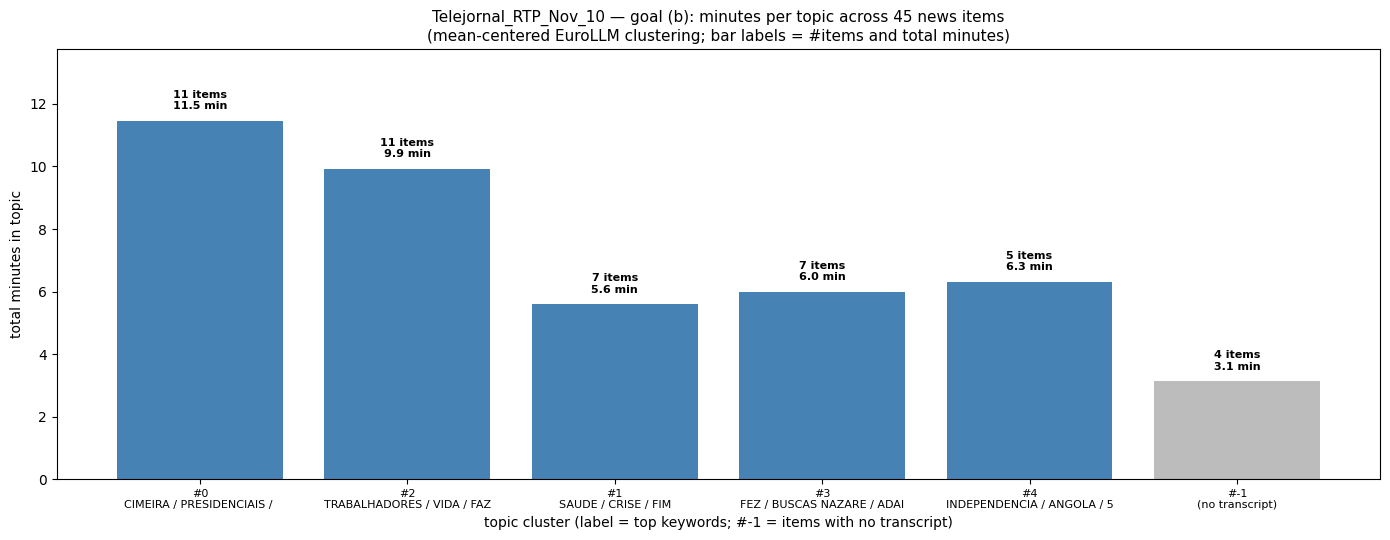

In [5]:
nov = cluster_topics(items[items.video == 'Telejornal_RTP_Nov_10'], max_k=8)
_ = plot_topic_bar(nov, 'Telejornal_RTP_Nov_10 — goal (b): minutes per topic across '
                   f'{len(nov)} news items\n(mean-centered EuroLLM clustering; bar labels = #items and total minutes)')

**News type breakdown** — each item is classified by keyword rules into politics / international / economy / sports / society / culture / weather (else *other*), on its headline + transcript.

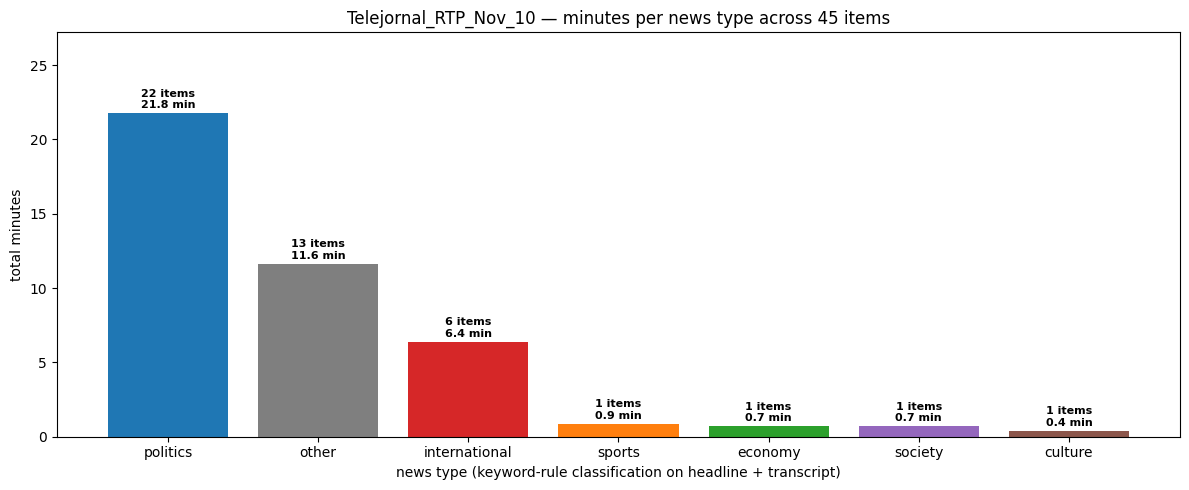

In [6]:
_ = plot_news_type_bar(nov, f'Telejornal_RTP_Nov_10 — minutes per news type across {len(nov)} items')

## Task 2 goal (a) — on-screen news stories & the anchor → news hand-offs

Goal (b) above counted topics and minutes. Goal (a) asks *when the broadcast moves from the anchor to a news story*. There is **no face/visual stream** for newscasts, so we read this from the **OCR story-headline graphics**: each story is announced from the studio and then carries a sustained lower-third headline strap. We detect those **sustained story straps** — their **onsets are the anchor → news hand-offs**, and the spans between them are studio links / cutaways with no story graphic. We then cross-check this OCR-native story count against the multimodal segmentation.

In [7]:
from difflib import SequenceMatcher
FRAME_W, FRAME_H = 1280, 720
CHANNEL_CHROME_CX_MIN, ZONE_LOWER_MAIN_WIDTH_FRAC = 0.72, 0.25
ZONE_ORDER = ['top', 'middle', 'lower_third_sub', 'lower_third_main', 'narrow_lower', 'channel_chrome', 'clock_bar']
def classify_zone(cx, cy, w):
    if cy < 0.20: return 'top'
    if cy < 0.70: return 'middle'
    if cy < 0.83: return 'lower_third_sub'
    if cy < 0.93:
        if cx >= CHANNEL_CHROME_CX_MIN: return 'channel_chrome'
        return 'lower_third_main' if w > ZONE_LOWER_MAIN_WIDTH_FRAC else 'narrow_lower'
    return 'clock_bar'
def ocr_zoned(video):
    o = seg['ocr'][seg['ocr'].video == video].dropna(subset=['time_s']).copy()
    cx = (o['x_center'] / FRAME_W).clip(0, 1); cy = (o['y_center'] / FRAME_H).clip(0, 1)
    w = ((o['x2'] - o['x1']) / FRAME_W).clip(0, 1)
    o['zone'] = [classify_zone(a, b, c) for a, b, c in zip(cx, cy, w)]
    o['sec'] = o['time_s'].round().astype(int)
    return o
def story_straps(video, dur_min=12, obs_min=4, sim=0.8, gap=120):
    # sustained, de-duplicated lower-third story headlines = the on-screen news stories
    h = seg['headline_intervals']
    h = h[(h.video == video) & (h.duration_s >= dur_min) & (h.observations >= obs_min)].sort_values('start_s')
    out = []
    for r in h.itertuples():
        if out:
            p = out[-1]; ratio = SequenceMatcher(None, p['headline'], r.headline).ratio()
            if (ratio >= sim or p['headline'] in r.headline or r.headline in p['headline']) and r.start_s - p['end_s'] <= gap:
                p['end_s'] = r.end_s; p['strap_s'] += (r.end_s - r.start_s); continue
        out.append(dict(headline=r.headline, start_s=r.start_s, end_s=r.end_s, strap_s=r.end_s - r.start_s))
    return pd.DataFrame([o for o in out if o['strap_s'] >= 10])

FOCUS = 'Telejornal_RTP_Nov_10'
oz = ocr_zoned(FOCUS)
chrome = oz.loc[oz.zone == 'channel_chrome', 'clean_text'].astype(str)
clock = oz.loc[oz.zone == 'clock_bar', 'text'].astype(str)
print('OCR zone sanity (channel-dependent persistent overlays, NOT used as the anchor signal):')
print(f"  channel_chrome rows naming the channel/programme : {chrome.str.contains('rtp|tvi|telejornal', case=False).mean() * 100:.0f}%")
print(f"  clock_bar rows matching a clock pattern           : {clock.str.contains(TIME_RE).mean() * 100:.0f}%")
straps = story_straps(FOCUS)
print(f"\n{FOCUS}: {len(straps)} sustained on-screen story headlines")
display(straps[['start_s', 'strap_s', 'headline']].head(20))

OCR zone sanity (channel-dependent persistent overlays, NOT used as the anchor signal):
  channel_chrome rows naming the channel/programme : 70%
  clock_bar rows matching a clock pattern           : 86%



Telejornal_RTP_Nov_10: 35 sustained on-screen story headlines


,start_s,strap_s,headline
0,7.0,12.0,"PM E A GREVE ""INTERESSES PARTIDÁRIOS"""
1,46.0,16.0,SELECÃO NACIONAL A 1 JOGO DO APURAMENTO
2,101.0,14.0,GREVE GERAL
3,138.0,12.0,CGTP DIZ QUE PM VIVE NUMA REALIDADE ENVIESADA
4,200.0,23.0,GREVE GERAL
5,325.0,49.0,BUSCAS NAZARÉ
6,449.0,21.0,TRABALHADORES COM FILHOS ATÉ 12 ANOS 📭
7,526.0,15.0,MINISTRA DO TRABALHO À RTP
8,541.0,34.0,GOVERNO QUER CONTINUAR A NEGOCIAR COM SINDICATOS
9,585.0,12.0,2º INQUÉRITO A DEPUTADO DO CHEGA


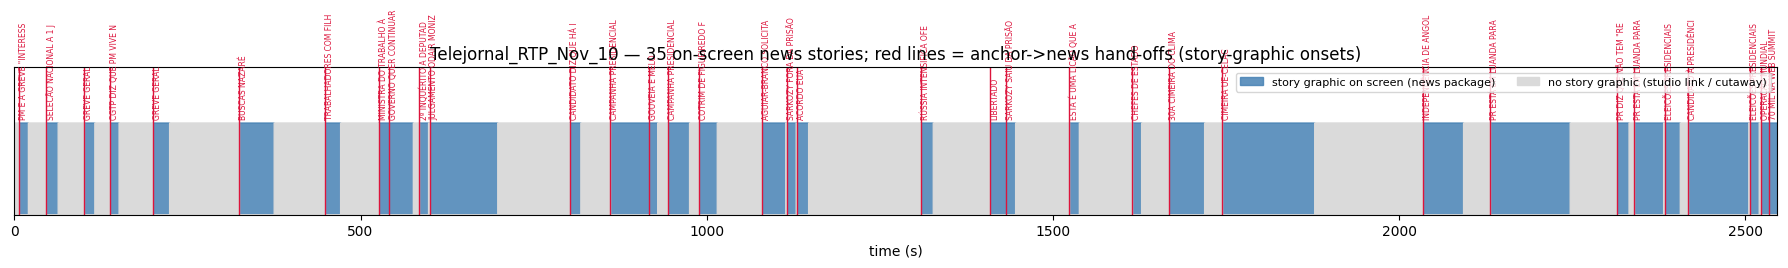

35 anchor->news hand-offs | story graphic on screen 46% of airtime | no story graphic 54%


In [8]:
# Timeline: story graphic on screen (news) vs no story graphic (studio link / cutaway); red = hand-offs
end = int(math.ceil(infer_video_end_s(sp[sp.video == FOCUS], seg['ocr'][seg['ocr'].video == FOCUS])))
graphic = np.zeros(end + 1, dtype=bool)
for r in straps.itertuples(): graphic[int(r.start_s):min(int(r.end_s), end) + 1] = True
fig, ax = plt.subplots(figsize=(18, 2.6))
ax.fill_between(range(end + 1), 0, graphic.astype(int), step='mid', color='steelblue', alpha=.85,
                label='story graphic on screen (news package)')
ax.fill_between(range(end + 1), 0, (~graphic).astype(int), step='mid', color='#dadada',
                label='no story graphic (studio link / cutaway)')
for r in straps.itertuples():
    ax.axvline(r.start_s, color='crimson', lw=1)
    ax.text(r.start_s, 1.03, r.headline[:22], rotation=90, va='bottom', fontsize=5.5, color='crimson')
ax.set_ylim(0, 1.6); ax.set_yticks([]); ax.set_xlim(0, end); ax.set_xlabel('time (s)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_title(f'{FOCUS} — {len(straps)} on-screen news stories; red lines = anchor->news hand-offs (story-graphic onsets)')
plt.tight_layout(); plt.show()
print(f'{len(straps)} anchor->news hand-offs | story graphic on screen {graphic.mean() * 100:.0f}% of airtime '
      f'| no story graphic {(~graphic).mean() * 100:.0f}%')

In [9]:
# Tag each segmented news item by whether a story graphic covers it, and cross-check the two story counts
def has_graphic(r, straps, frac=0.30):
    if not len(straps): return False
    ov = np.maximum(0, np.minimum(straps.end_s, r.end_s) - np.maximum(straps.start_s, r.start_s)).sum()
    return ov >= frac * (r.end_s - r.start_s)
its = items[items.video == FOCUS].copy()
its['on_screen_story'] = [has_graphic(r, straps) for r in its.itertuples()]
its['segment_type'] = np.where(its['on_screen_story'], 'news package (graphic)', 'studio / link')
print(f"{FOCUS}: multimodal engine items = {len(its)} | OCR on-screen story headlines = {len(straps)}")
print(f"  engine items carrying a story graphic: {int(its['on_screen_story'].sum())} | studio/link items: {int((~its['on_screen_story']).sum())}")
print("  (the engine over-segments long reports; the OCR story-strap count is a more parsimonious 'how many stories' signal)")
display(its[['item_id', 'start_s', 'duration_s', 'segment_type', 'headline']].head(20))

Telejornal_RTP_Nov_10: multimodal engine items = 45 | OCR on-screen story headlines = 35
  engine items carrying a story graphic: 24 | studio/link items: 21
  (the engine over-segments long reports; the OCR story-strap count is a more parsimonious 'how many stories' signal)


,item_id,start_s,duration_s,segment_type,headline
189,1,0.0,46.0,studio / link,"PM E A GREVE ""INTERESSES PARTIDÁRIOS"""
190,2,46.0,52.0,news package (graphic),SELECÃO NACIONAL A 1 JOGO DO APURAMENTO
191,3,98.0,52.0,news package (graphic),GREVE GERAL
192,4,150.0,35.0,studio / link,REGISTRO / RE
193,5,185.0,39.0,news package (graphic),GREVE GERAL
194,6,224.0,39.0,studio / link,OPERACÃO DUNAS
195,7,263.0,42.0,studio / link,POLÍCIA JUDICIÁRIA FEZ BUSCAS NA C.M. DA NAZARÉ
196,8,305.0,72.0,news package (graphic),BUSCAS NAZARÉ
197,9,377.0,45.0,studio / link,LIMITAR DISPENSA DE AMAMENTACÃO ATÉ AOS 2 ANOS
198,10,422.0,55.0,news package (graphic),TRABALHADORES COM FILHOS ATÉ 12 ANOS 📭


**How to read this, honestly.** With no face/visual stream we cannot see the anchor directly, so we detect the **story-headline graphic** instead. Its onset is a reliable *anchor → news* hand-off, but the *no story graphic* spans mix true studio links with graphic-less package footage (B-roll, interviews), so they are **not** a clean "anchor-only" measure. A strap that changes mid-report can also be counted as two stories. The cross-check above shows the OCR story count is *more* parsimonious than the multimodal engine's item count, which tends to over-segment long reports.

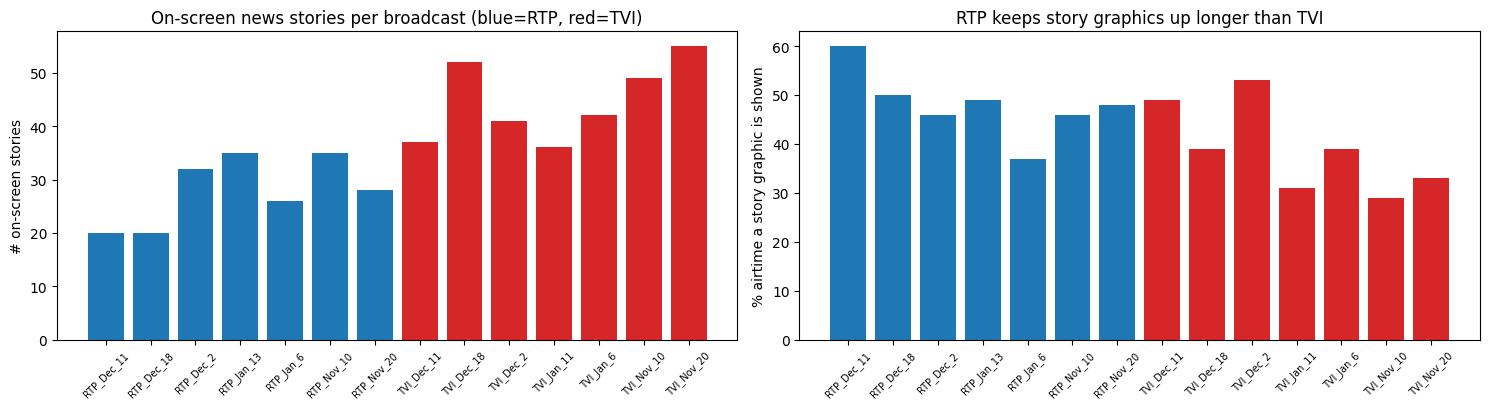

         minutes  stories  graphic_pct
channel                               
RTP         43.6     28.0         48.0
TVI         71.9     44.6         39.0


In [10]:
# Across all 14 broadcasts: on-screen story count and how long a story graphic stays up (RTP vs TVI)
_sr = []
for v in all_ns:
    st = story_straps(v); e = int(math.ceil(infer_video_end_s(sp[sp.video == v], seg['ocr'][seg['ocr'].video == v])))
    g = np.zeros(e + 1, dtype=bool)
    for r in st.itertuples(): g[int(r.start_s):min(int(r.end_s), e) + 1] = True
    _sr.append(dict(video=v.replace('Telejornal_', ''), channel='RTP' if 'RTP' in v else 'TVI',
                    minutes=round(e / 60), stories=len(st), graphic_pct=round(g.mean() * 100)))
strap_summary = pd.DataFrame(_sr)
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
col = ['#1f77b4' if c == 'RTP' else '#d62728' for c in strap_summary.channel]
ax[0].bar(strap_summary.video, strap_summary.stories, color=col); ax[0].set_ylabel('# on-screen stories')
ax[0].tick_params(axis='x', rotation=45, labelsize=7); ax[0].set_title('On-screen news stories per broadcast (blue=RTP, red=TVI)')
ax[1].bar(strap_summary.video, strap_summary.graphic_pct, color=col); ax[1].set_ylabel('% airtime a story graphic is shown')
ax[1].tick_params(axis='x', rotation=45, labelsize=7); ax[1].set_title('RTP keeps story graphics up longer than TVI')
plt.tight_layout(); plt.show()
print(strap_summary.groupby('channel')[['minutes', 'stories', 'graphic_pct']].mean().round(1).to_string())

## Is one modality enough to characterise the videos?

The brief asks this directly. Newscasts give two modalities — dense **OCR** (every second) and **sparse speech** (EuroLLM transcript embeddings on only part of the timeline). Below we ablate each: first for **segmentation** (can a single modality find the news-item boundaries?), then for **topic characterisation** (do speech-only and OCR-only clusterings agree?).

,video,combined,speech_only,ocr_only,speech_recall,ocr_recall,speech_visibility
0,RTP_Dec_11,51,11,51,0.12,0.94,0.45
1,RTP_Dec_18,24,2,24,0.00,1.00,0.23
2,RTP_Dec_2,52,10,53,0.10,0.92,0.46
3,RTP_Jan_13,56,14,56,0.09,1.00,0.42
4,RTP_Jan_6,55,9,55,0.09,0.91,0.36
5,RTP_Nov_10,51,8,52,0.12,1.00,0.31
6,RTP_Nov_20,51,9,53,0.04,0.94,0.34
7,TVI_Dec_11,71,20,72,0.15,0.87,0.58
8,TVI_Dec_18,72,21,71,0.21,0.85,0.52
9,TVI_Dec_2,98,30,99,0.13,0.83,0.61


On average OCR alone recovers 91% of the combined boundaries; speech alone 12% — and speech can only 'see' 45% of the timeline (the rest carries no transcript).


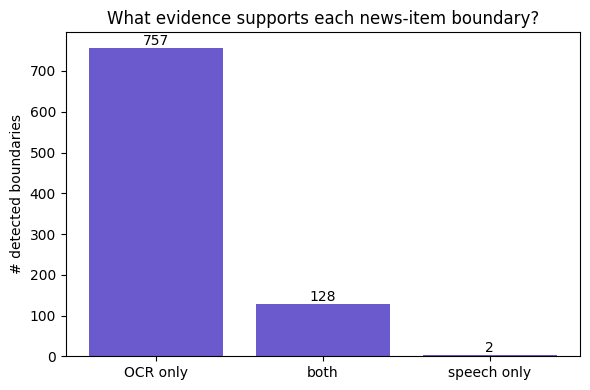

In [11]:
from sklearn.metrics import adjusted_rand_score
SIG_KEYS = ['semantic_shift', 'ocr_headline_shift', 'ocr_layout_shift', 'face_shift', 'speaker_shift']
def _signals(video):
    sv = sp[sp.video == video]; ov = seg['ocr'][seg['ocr'].video == video]
    hv = seg['headline_intervals'][seg['headline_intervals'].video == video]
    cfg = SegmentationConfig(features_dir=FEATURES_DIR, raw_video_dir=None)
    end = infer_video_end_s(sv, ov, hv); n = int(math.ceil(end)) + 1
    S = {k: np.zeros(n) for k in SIG_KEYS}
    _place_points(S['semantic_shift'], compute_semantic_shift(sv, cfg.semantic_window_segments))
    _place_points(S['ocr_headline_shift'], [(float(r.start_s), 1.0) for r in hv.itertuples() if float(r.start_s) > cfg.min_item_duration_s])
    _place_points(S['ocr_layout_shift'], compute_ocr_layout_shift(ov))
    for k in S: S[k] = np.maximum(normalize_signal(S[k]), smooth_signal(normalize_signal(S[k]), radius=2))
    return S, hv, sv, end, cfg
def boundaries_modality(video, modality):
    S, hv, sv, end, cfg = _signals(video)
    if modality == 'speech':                                   # semantic shift only; OCR fully suppressed
        Sz = {k: (S['semantic_shift'] if k == 'semantic_shift' else np.zeros_like(S[k])) for k in SIG_KEYS}
        return select_boundaries(S['semantic_shift'].copy(), Sz, pd.DataFrame(columns=HEADLINE_COLUMNS), sv, end, cfg)
    w = {'ocr_headline_shift': 0.25, 'ocr_layout_shift': 0.15}; tot = sum(w.values())   # OCR signals only
    Sz = {k: (np.zeros_like(S[k]) if k == 'semantic_shift' else S[k]) for k in SIG_KEYS}
    return select_boundaries(sum(w[k] / tot * S[k] for k in w), Sz, hv, pd.DataFrame(columns=['start_s']), end, cfg)
def recovered(ref, test, tol=10.0): return sum(any(abs(r - t) <= tol for t in test) for r in ref)
_ar = []
for v in all_ns:
    comb = sorted(seg['newscast_boundaries'].query('video == @v')['boundary_s'].tolist())
    sb, ob = boundaries_modality(v, 'speech'), boundaries_modality(v, 'ocr')
    sv = sp[sp.video == v]; e = infer_video_end_s(sv, seg['ocr'][seg['ocr'].video == v])
    _ar.append(dict(video=v.replace('Telejornal_', ''), combined=len(comb), speech_only=len(sb), ocr_only=len(ob),
                    speech_recall=round(recovered(comb, sb) / max(len(comb), 1), 2),
                    ocr_recall=round(recovered(comb, ob) / max(len(comb), 1), 2),
                    speech_visibility=round(sv['duration'].sum() / max(e, 1), 2)))
ablation = pd.DataFrame(_ar); display(ablation)
print(f"On average OCR alone recovers {ablation.ocr_recall.mean() * 100:.0f}% of the combined boundaries; "
      f"speech alone {ablation.speech_recall.mean() * 100:.0f}% — and speech can only 'see' "
      f"{ablation.speech_visibility.mean() * 100:.0f}% of the timeline (the rest carries no transcript).")
def _ev(f):
    s = {x for x in str(f).split(',') if x}; o = bool(s & {'ocr_headline', 'ocr_layout'}); m = 'semantic' in s
    return 'both' if o and m else 'OCR only' if o else 'speech only' if m else 'other'
cats = seg['newscast_boundaries']['evidence_flags'].map(_ev).value_counts()
fig, ax = plt.subplots(figsize=(6, 4)); ax.bar(cats.index, cats.values, color='slateblue')
for i, val in enumerate(cats.values): ax.text(i, val, str(val), ha='center', va='bottom')
ax.set_ylabel('# detected boundaries'); ax.set_title('What evidence supports each news-item boundary?')
plt.tight_layout(); plt.show()

In [12]:
# Topic characterisation with ONE modality: speech embeddings vs OCR-headline text
emb_mask = items['emb'].apply(lambda x: isinstance(x, np.ndarray)).values
hl = items['headline'].fillna('NO OCR HEADLINE'); ocr_mask = (hl != 'NO OCR HEADLINE').values
k = min(10, max(2, round(math.sqrt(emb_mask.sum()))))
def _km(M):
    M = M - M.mean(0); M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
    return KMeans(k, n_init=10, random_state=RANDOM_STATE).fit_predict(M)
sp_lab = np.full(len(items), -1); sp_lab[emb_mask] = _km(np.vstack(items.loc[emb_mask, 'emb'].values).astype(float))
ocr_lab = np.full(len(items), -1)
Xo = TfidfVectorizer(max_features=2000, stop_words=list(ns.PT_STOPWORDS), strip_accents='unicode').fit_transform(hl[ocr_mask]).toarray()
ocr_lab[ocr_mask] = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xo)
both = emb_mask & ocr_mask
print(f'{len(items)} news items | invisible to SPEECH (no transcript): {int((~emb_mask).sum())} ({(~emb_mask).mean() * 100:.0f}%) '
      f'| invisible to OCR (no headline): {int((~ocr_mask).sum())} ({(~ocr_mask).mean() * 100:.0f}%)')
print(f'speech-topics vs OCR-topics agreement (adjusted Rand on {int(both.sum())} co-labelled items): {adjusted_rand_score(sp_lab[both], ocr_lab[both]):.2f}')
print('\nVerdict - neither modality alone is sufficient, and they are asymmetric:')
print('  - OCR (dense) recovers the broadcast STRUCTURE and covers 100% of the timeline, but its short headlines barely cluster into topics;')
print('  - speech (sparse) carries the topic MEANING, but only on the ~25-64% of airtime it transcribes.')
print('  The two clusterings hardly agree (low ARI): each captures a different facet, so the combined view above is what answers "what aired, and for how long".')

724 news items | invisible to SPEECH (no transcript): 183 (25%) | invisible to OCR (no headline): 0 (0%)
speech-topics vs OCR-topics agreement (adjusted Rand on 541 co-labelled items): 0.01

Verdict - neither modality alone is sufficient, and they are asymmetric:
  - OCR (dense) recovers the broadcast STRUCTURE and covers 100% of the timeline, but its short headlines barely cluster into topics;
  - speech (sparse) carries the topic MEANING, but only on the ~25-64% of airtime it transcribes.
  The two clusterings hardly agree (low ARI): each captures a different facet, so the combined view above is what answers "what aired, and for how long".


## All newscasts — topics across every transmission

The same view over all 14 broadcasts combined: which topics dominated the two-month window.

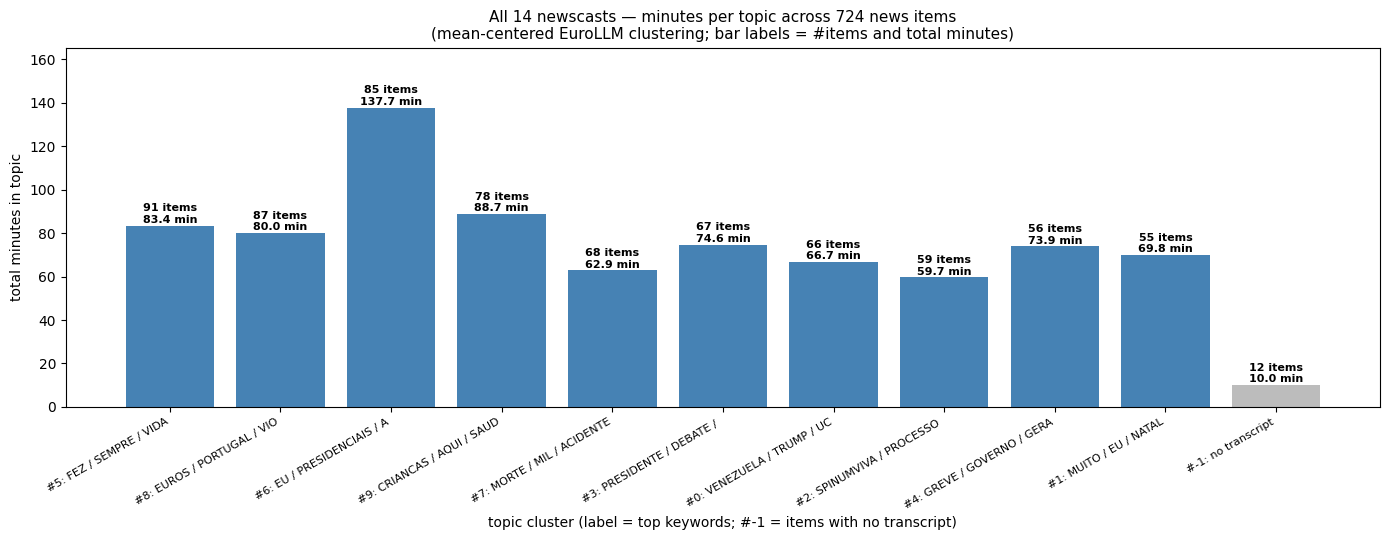

In [13]:
allc = cluster_topics(items, max_k=10)
_ = plot_topic_bar(allc, f'All {items.video.nunique()} newscasts — minutes per topic across '
                   f'{len(allc)} news items\n(mean-centered EuroLLM clustering; bar labels = #items and total minutes)')

**News type across all transmissions** — the same keyword-rule classification over every newscast.

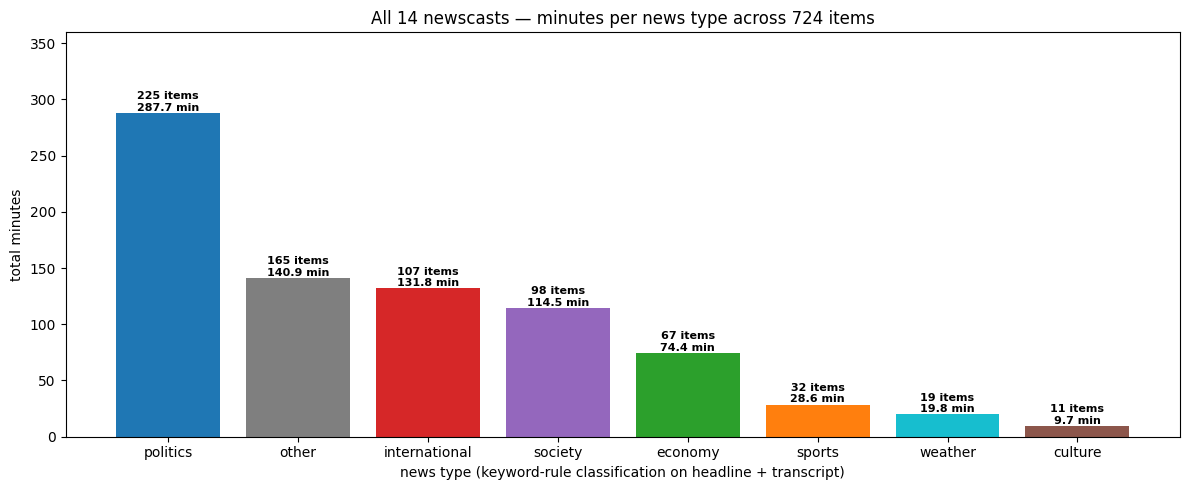

In [14]:
_ = plot_news_type_bar(allc, f'All {allc.video.nunique()} newscasts — minutes per news type across {len(allc)} items')

## Same story on both channels — RTP vs TVI airtime

On the days both channels were recorded, each RTP item is matched to its mutual-nearest-neighbour TVI
item (centered-cosine ≥ 0.55 = "same story"). We then compare how much airtime each channel gave it
and which channel ran it earlier.

30 cross-channel story matches across 5 shared days


,day,sim,rtp_headline,tvi_headline,aired_first
0,Dec_11,0.803,CARTAZES INCENDIADOS JUNTO AO PARLAMENTO,GREVE GERAL EM TODO O PAÍS,TVI
1,Dec_11,0.719,GREVE GERAL,MAIS DE 800 COMBOIOS FORAM CANCELADOS,RTP
2,Dec_11,0.659,GREVE GERAL,GREVE GERAL EM TODO O PAÍS,RTP
3,Dec_11,0.617,GREVE GERAL,GREVE: ENSINO PARALISADO,RTP
4,Dec_11,0.598,"""VAI AUMENTAR AINDA MAIS A PRECARIEDADE""",MAIS DE TRÊS MILHÕES DE PESSOAS ADERIRAM À PARALISACÃO,TVI
5,Dec_2,0.716,PRESIDENTE OPERADO,PRESIDENTE ESTÁ FORA DE PERIGO E A RECUPERAR,TVI
6,Dec_2,0.684,RÚSSIA AVISA EUROPA,PLANO DE PAZ PARA A UCRÂNIA,RTP
7,Dec_2,0.675,ENCONTRO RÚSSIA - EUA,MOSCOVO GANHA TERRENO,RTP
8,Dec_2,0.667,VENDA DE CARROS AUMENTA,CUNHA E SÁ AVANCOU EM 1.ª MÃO SAÍDA DE PINA MOURA,RTP
9,Dec_2,0.662,MARCELO NO HOSPITAL,PÓS-OPERATÓRIO OBRIGA A ALGUNS CUIDADOS,TVI


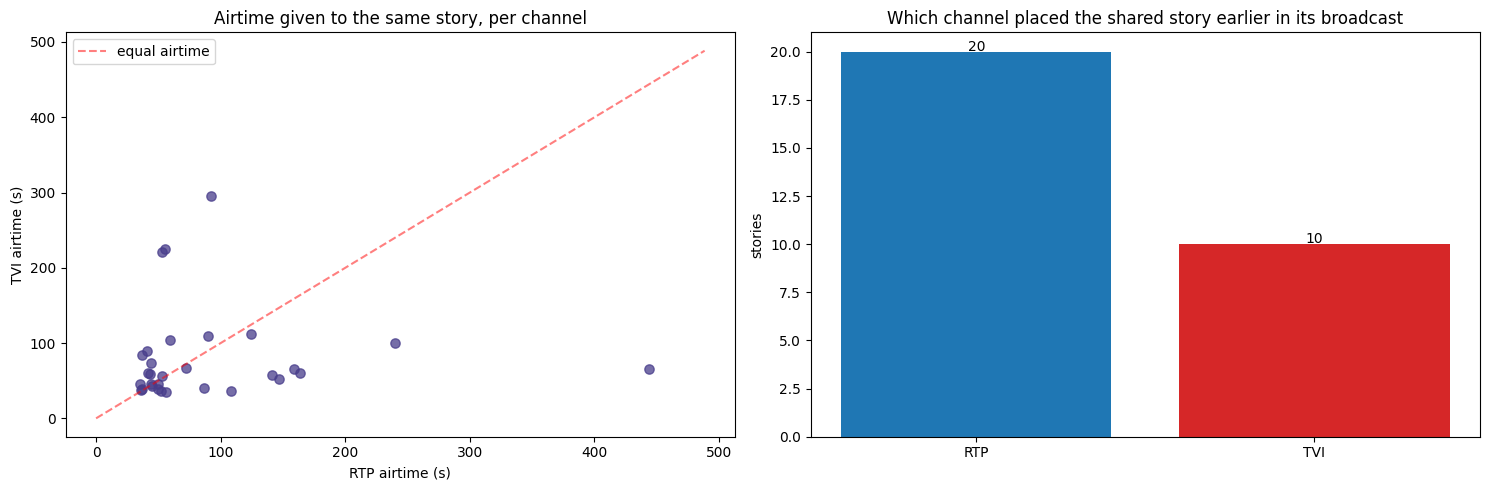

In [15]:
items_emb = items[items['emb'].apply(lambda x: isinstance(x, np.ndarray))].reset_index(drop=True)
NIc = np.vstack(items_emb['emb'].values); NIc = NIc - NIc.mean(0, keepdims=True)   # mean-centered (de-anisotropy)
matches = []
for day in SHARED_DAYS:
    r = items_emb[(items_emb.day == day) & (items_emb.channel == 'RTP')]
    t = items_emb[(items_emb.day == day) & (items_emb.channel == 'TVI')]
    if not len(r) or not len(t): continue
    S = cosine_similarity(NIc[r.index], NIc[t.index]); rb, tb = S.argmax(1), S.argmax(0)
    for i in range(len(r)):
        j = int(rb[i])
        if tb[j] == i and S[i, j] >= MATCH_MIN:
            ri, ti = r.iloc[i], t.iloc[j]
            matches.append(dict(day=day, sim=round(float(S[i, j]), 3),
                                rtp_headline=ri.headline, tvi_headline=ti.headline,
                                rtp_dur_s=round(ri.duration_s), tvi_dur_s=round(ti.duration_s),
                                aired_first='RTP' if ri.start_s <= ti.start_s else 'TVI'))
cross = pd.DataFrame(matches).sort_values(['day', 'sim'], ascending=[True, False]).reset_index(drop=True)
print(f'{len(cross)} cross-channel story matches across {cross.day.nunique()} shared days')
display(cross[['day', 'sim', 'rtp_headline', 'tvi_headline', 'aired_first']].head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(cross['rtp_dur_s'], cross['tvi_dur_s'], c='darkslateblue', alpha=0.75, s=45)
lim = max(cross['rtp_dur_s'].max(), cross['tvi_dur_s'].max()) * 1.1
axes[0].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='equal airtime')
axes[0].set_xlabel('RTP airtime (s)'); axes[0].set_ylabel('TVI airtime (s)')
axes[0].set_title('Airtime given to the same story, per channel'); axes[0].legend()
fc = cross['aired_first'].value_counts()
axes[1].bar(fc.index, fc.values, color=['#1f77b4', '#d62728'])
axes[1].set_ylabel('stories'); axes[1].set_title('Which channel placed the shared story earlier in its broadcast')
for i, v in enumerate(fc.values): axes[1].text(i, v + 0.05, str(int(v)), ha='center')
plt.tight_layout(); plt.show()

## Candidate mentions vs polls over time

Per candidate: newscast **mention-minutes** (airtime of items naming them, transcript + OCR, summed
across RTP + TVI) as blue bars, against their **poll %** (red line) across Oct → Jan.

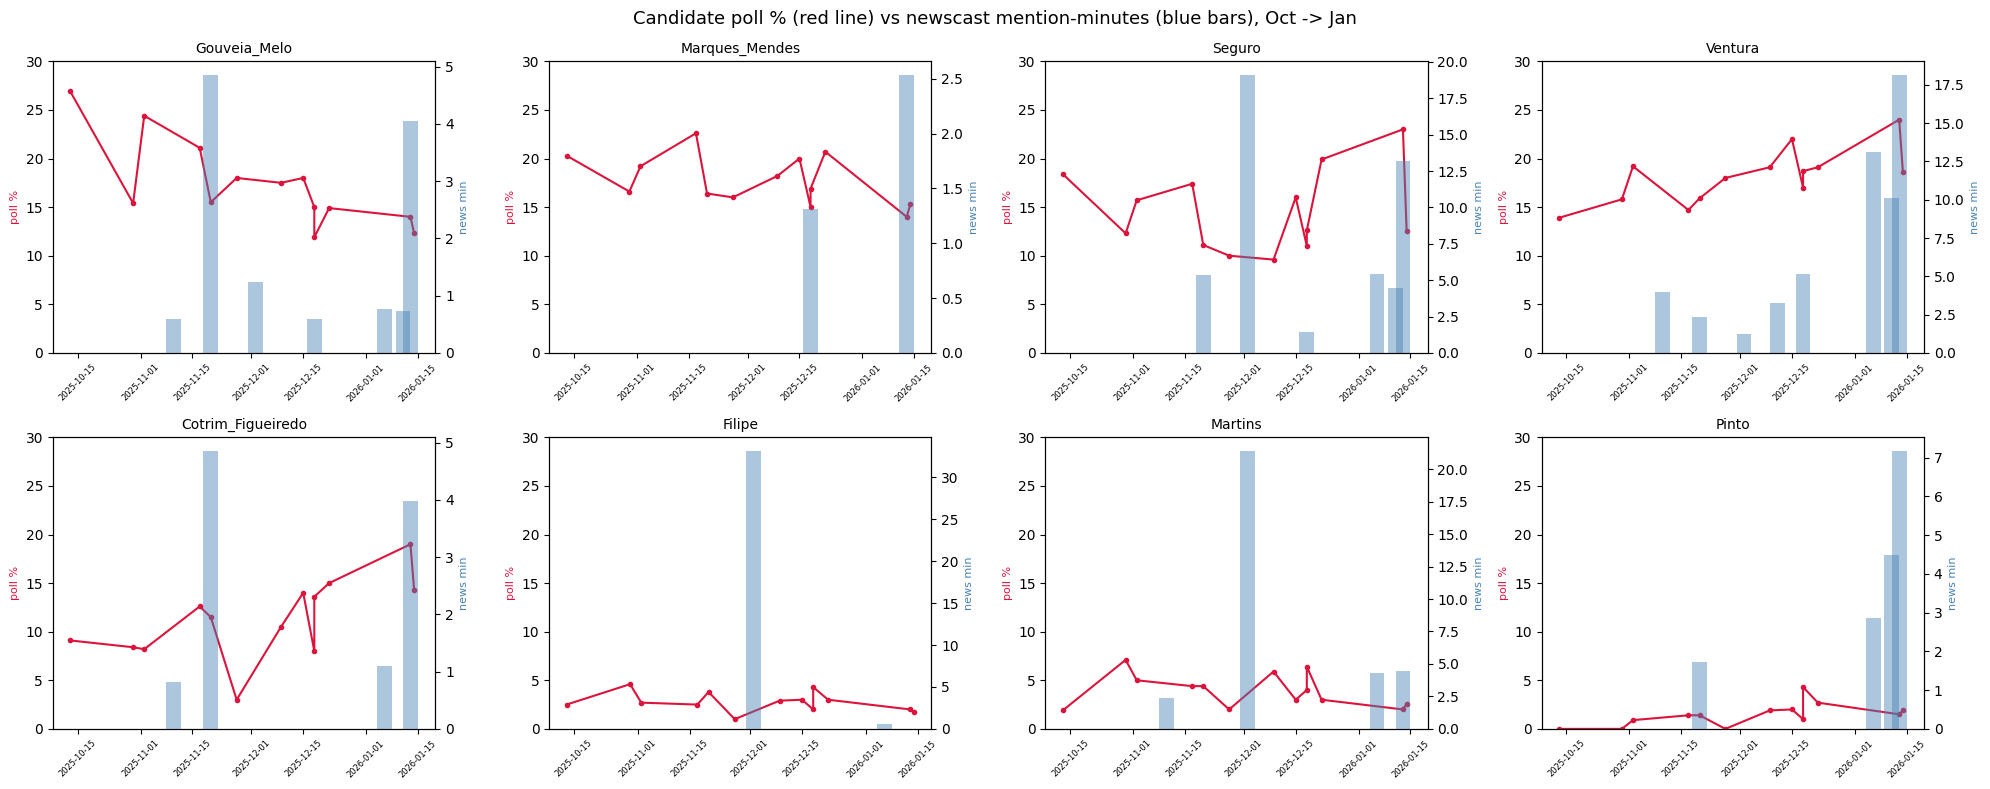

In [16]:
_rows = [(it.date, c, it.duration_s / 60.0) for it in items.itertuples() for c in it.cands]
mentions_ts = (pd.DataFrame(_rows, columns=['date', 'candidate', 'minutes'])
               .groupby(['date', 'candidate'])['minutes'].sum().reset_index())
polls = pd.read_pickle(f'{FEATURES_DIR}/polls_timeline.pkl')
polls['date_d'] = polls['date'].map(day_to_date); polls = polls.sort_values('date_d').reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 8)); axes = axes.ravel()
for ax, c in zip(axes, CANDS):
    ax.plot(polls['date_d'], polls[c], '-o', ms=3, color='crimson'); ax.set_ylim(0, 30)
    ax.set_ylabel('poll %', color='crimson', fontsize=8); ax.set_title(c, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    m = mentions_ts[mentions_ts.candidate == c].sort_values('date'); ax2 = ax.twinx()
    ax2.bar(m['date'], m['minutes'], width=4, alpha=0.45, color='steelblue')
    ax2.set_ylabel('news min', color='steelblue', fontsize=8)
fig.suptitle('Candidate poll % (red line) vs newscast mention-minutes (blue bars), Oct -> Jan', fontsize=13)
plt.tight_layout(); plt.show()

## Poll & coverage volatility

How much each candidate's support and coverage swung. The bar ranks **poll volatility** (std of poll %,
annotated with peak-to-trough swing); the scatter asks whether heavier coverage goes with steadier or
shakier polling. *(n = 8 candidates / ≤12 polls — indicative.)*

,candidate,poll_mean,poll_std,poll_swing,poll_change_std,mention_min_total,mention_std
0,Gouveia_Melo,17.3,4.31,15.0,4.79,12.8,1.82
1,Seguro,14.6,4.01,13.4,5.26,49.0,6.61
2,Cotrim_Figueiredo,11.3,3.92,16.0,4.72,10.8,2.03
3,Ventura,18.2,2.69,10.1,3.29,57.3,6.02
4,Marques_Mendes,17.8,2.49,8.6,3.72,3.8,0.86
5,Martins,4.0,1.68,5.2,2.60,32.5,8.89
6,Pinto,1.5,1.15,4.3,1.37,16.2,2.37
7,Filipe,2.8,0.98,3.6,1.59,33.8,22.98


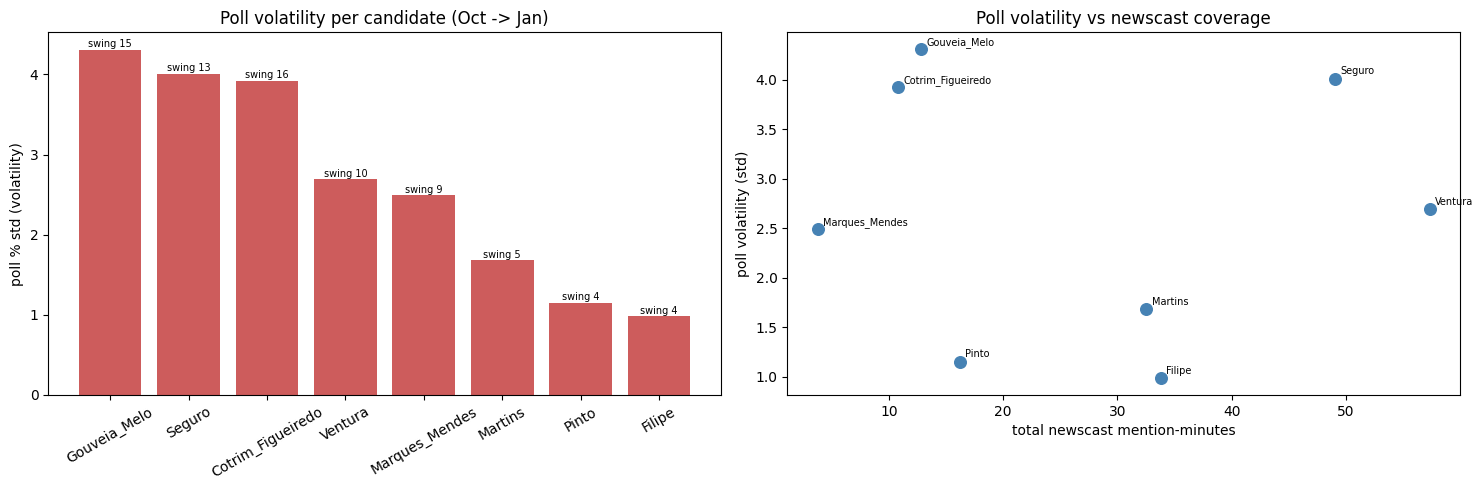

In [17]:
vol = []
for c in CANDS:
    p = polls[c].astype(float).values; mm = mentions_ts[mentions_ts.candidate == c]['minutes']
    vol.append(dict(candidate=c, poll_mean=round(p.mean(), 1), poll_std=round(p.std(), 2),
                    poll_swing=round(p.max() - p.min(), 1), poll_change_std=round(np.std(np.diff(p)), 2),
                    mention_min_total=round(mm.sum(), 1), mention_std=round(mm.std() if len(mm) > 1 else 0.0, 2)))
volatility = pd.DataFrame(vol).sort_values('poll_std', ascending=False).reset_index(drop=True)
display(volatility)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(volatility['candidate'], volatility['poll_std'], color='indianred')
axes[0].set_ylabel('poll % std (volatility)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Poll volatility per candidate (Oct -> Jan)')
for i, r in volatility.iterrows():
    axes[0].text(i, r['poll_std'] + 0.03, f"swing {r['poll_swing']:.0f}", ha='center', fontsize=7)
axes[1].scatter(volatility['mention_min_total'], volatility['poll_std'], s=70, color='steelblue')
for _, r in volatility.iterrows():
    axes[1].annotate(r['candidate'], (r['mention_min_total'], r['poll_std']),
                     fontsize=7, xytext=(4, 3), textcoords='offset points')
axes[1].set_xlabel('total newscast mention-minutes'); axes[1].set_ylabel('poll volatility (std)')
axes[1].set_title('Poll volatility vs newscast coverage')
plt.tight_layout(); plt.show()

# Task 3 — additional connections

Three further questions from the brief, built on the items and embeddings already computed above:

- **Embedding structure** — are the 4096-dim EuroLLM features correlated / reducible? (this also motivates the mean-centering used throughout)
- **Debate ↔ newscast** — do newscast stories echo what was said in the debates? *(links to the debate side of the project)*
- **Predicting poll evolution** — does coverage lead the polls? *(tiny N — exploratory)*

First load the debate transcripts (same EuroLLM schema as the newscasts) so they can be compared directly.

In [18]:
# Load debate transcripts (identical EuroLLM speech schema) for the cross-links below
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
DEBATE_FILES = sorted(glob.glob(f'{FEATURES_DIR}/*_vs_*_speech.pkl'))
_DBMON = re.compile(r'_(October|November|December|January|Oct|Nov|Dec|Jan)_(\d{1,2})$')
def parse_debate_stem(stem):
    left, right = stem.split('_vs_', 1); m = _DBMON.search(right)
    y, mo = MONTHS[m.group(1)]; return left, right[:m.start()], date(y, mo, int(m.group(2)))
def _mean_emb(df):
    es = [e for e in df['text_embedding'] if isinstance(e, np.ndarray) and e.size]
    return np.vstack(es).astype(float).mean(0) if es else None
_dr = []
for f in DEBATE_FILES:
    stem = re.sub(r'_speech\.pkl$', '', f.split('/')[-1]); a, b, d = parse_debate_stem(stem)
    dfd = pd.read_pickle(f)
    _dr.append(dict(debate=stem, candA=a, candB=b, date=d, n_seg=len(dfd), emb=_mean_emb(dfd)))
debates = pd.DataFrame(_dr)
debates = debates[debates['emb'].apply(lambda x: isinstance(x, np.ndarray))].reset_index(drop=True)
print(f'{len(debates)} debates loaded, {debates.date.min()} -> {debates.date.max()}; '
      f'all participants are known candidates: {set(debates.candA) | set(debates.candB) <= set(CANDS)}')
display(debates[['debate', 'candA', 'candB', 'date', 'n_seg']].head(6))

28 debates loaded, 2025-11-17 -> 2025-12-21; all participants are known candidates: True


,debate,candA,candB,date,n_seg
0,Cotrim_Figueiredo_vs_Filipe_November_30,Cotrim_Figueiredo,Filipe,2025-11-30,33
1,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Cotrim_Figueiredo,Gouveia_Melo,2025-11-20,19
2,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,Cotrim_Figueiredo,Marques_Mendes,2025-12-07,33
3,Cotrim_Figueiredo_vs_Ventura_December_19,Cotrim_Figueiredo,Ventura,2025-12-19,37
4,Filipe_vs_Gouveia_Melo_December_2,Filipe,Gouveia_Melo,2025-12-02,21
5,Filipe_vs_Marques_Mendes_November_18,Filipe,Marques_Mendes,2025-11-18,33


## Embedding structure & dimensionality reduction

*Are there highly correlated features? Can we reduce the dimensionality?* The news-item EuroLLM embeddings are 4096-dimensional but far from full-rank. The left plot shows EuroLLM's **anisotropy** — raw embeddings are nearly co-linear (pairwise cosine piles up near 1), which is exactly why every similarity step in this notebook **mean-centers first**. The right plot reports the **intrinsic dimensionality**: how few principal components already capture 90% of the variance.

541 items x 4096 dims | mean pairwise cosine: raw 0.93 -> mean-centered -0.00
intrinsic dimensionality: 99 PCs reach 90% variance, 168 reach 95% (of 4096) -> highly correlated / compressible


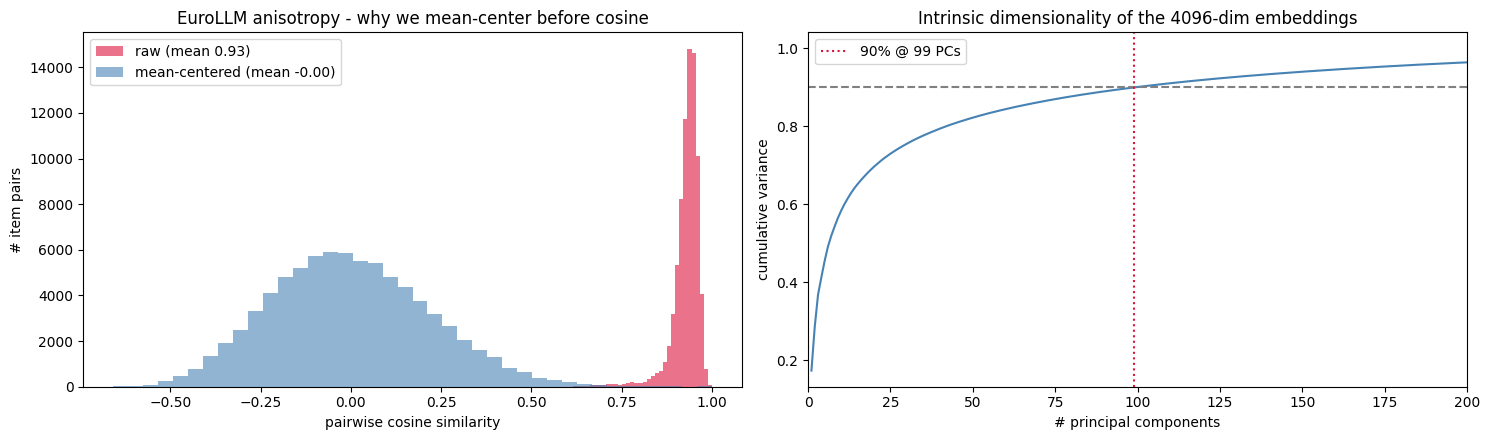

In [19]:
E_all = np.vstack(items_emb['emb'].values).astype(float)            # (n_items, 4096)
rng = np.random.RandomState(RANDOM_STATE); idx = rng.choice(len(E_all), min(400, len(E_all)), replace=False)
def _offdiag_cos(M):
    C = cosine_similarity(M); return C[np.triu_indices_from(C, 1)]
raw_c = _offdiag_cos(E_all[idx]); cen_c = _offdiag_cos(E_all[idx] - E_all.mean(0))
p = PCA().fit(E_all); cum = np.cumsum(p.explained_variance_ratio_)
k90 = int(np.searchsorted(cum, .9) + 1); k95 = int(np.searchsorted(cum, .95) + 1)
print(f'{E_all.shape[0]} items x {E_all.shape[1]} dims | mean pairwise cosine: raw {raw_c.mean():.2f} -> mean-centered {cen_c.mean():.2f}')
print(f'intrinsic dimensionality: {k90} PCs reach 90% variance, {k95} reach 95% (of 4096) -> highly correlated / compressible')
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].hist(raw_c, bins=40, alpha=.6, color='crimson', label=f'raw (mean {raw_c.mean():.2f})')
ax[0].hist(cen_c, bins=40, alpha=.6, color='steelblue', label=f'mean-centered (mean {cen_c.mean():.2f})')
ax[0].set_xlabel('pairwise cosine similarity'); ax[0].set_ylabel('# item pairs')
ax[0].set_title('EuroLLM anisotropy - why we mean-center before cosine'); ax[0].legend()
ax[1].plot(range(1, len(cum) + 1), cum, color='steelblue'); ax[1].axhline(.9, ls='--', color='grey')
ax[1].axvline(k90, ls=':', color='crimson', label=f'90% @ {k90} PCs'); ax[1].set_xlim(0, 200)
ax[1].set_xlabel('# principal components'); ax[1].set_ylabel('cumulative variance')
ax[1].set_title('Intrinsic dimensionality of the 4096-dim embeddings'); ax[1].legend()
plt.tight_layout(); plt.show()

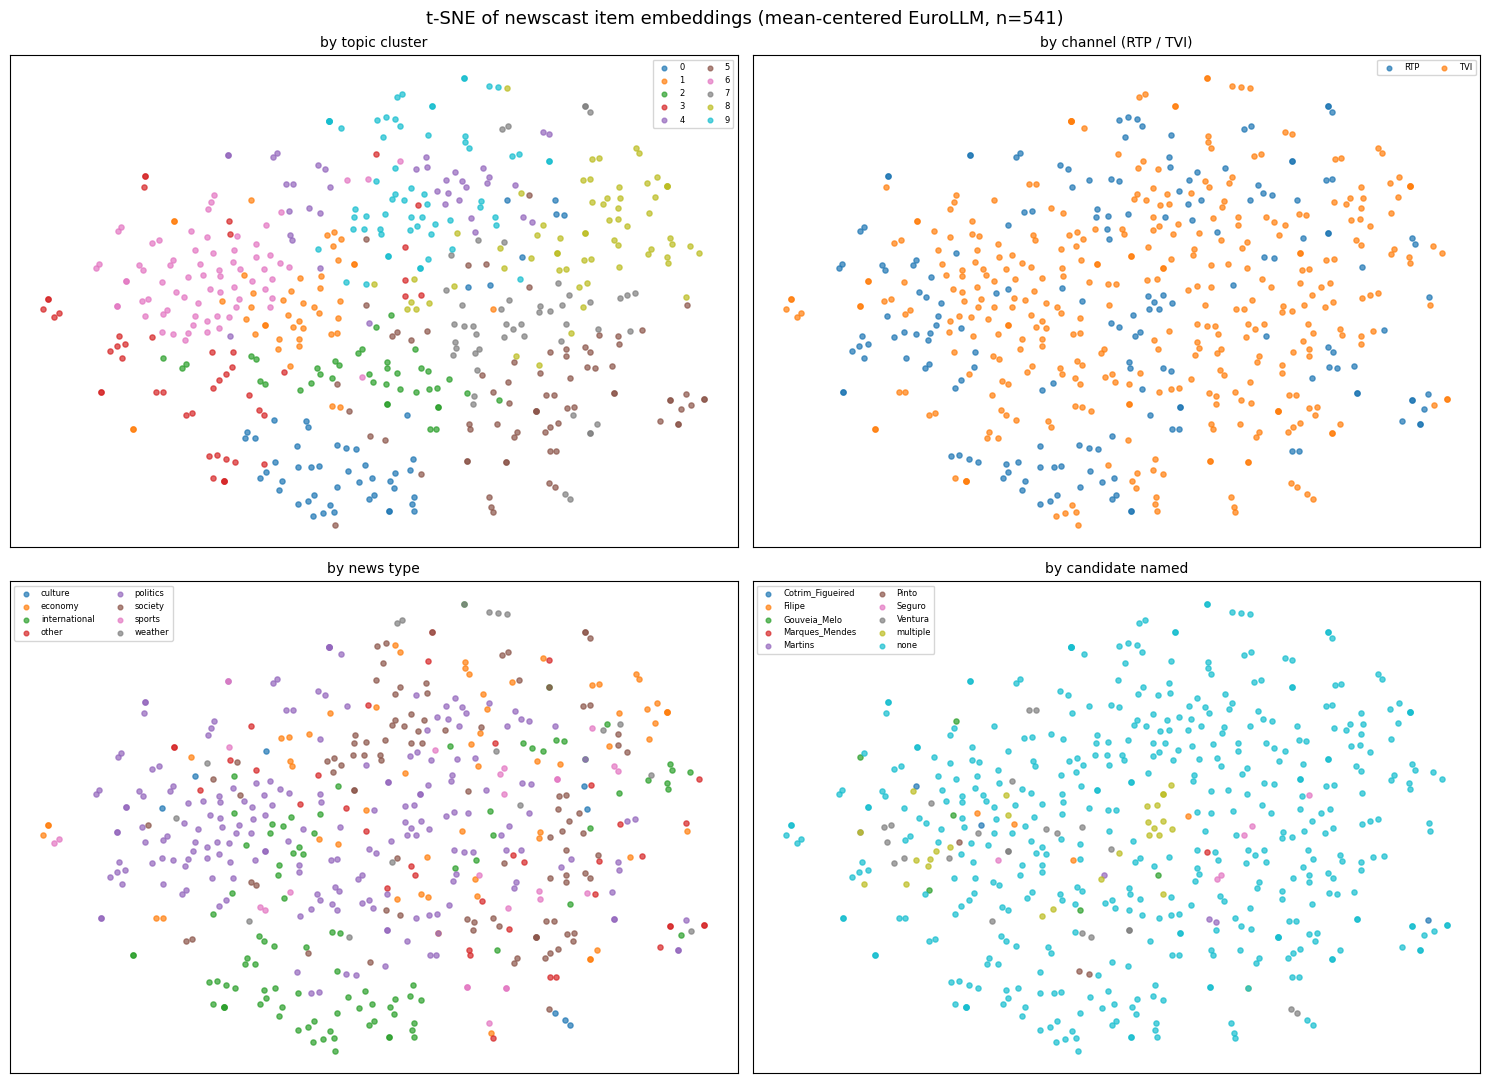

In [20]:
# 2D map of the item embedding space (mean-centered EuroLLM), coloured four ways
_lab = allc[['video', 'item_id', 'topic_cluster', 'topic_label']]
ie = items_emb.merge(_lab, on=['video', 'item_id'], how='left', suffixes=('', '_c'))
ie['news_type'] = ie['item_text'].map(classify_news_type)
ie['cand'] = ie['cands'].map(lambda s: next(iter(s)) if len(s) == 1 else ('multiple' if len(s) > 1 else 'none'))
Ec = E_all - E_all.mean(0)
Zt = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca',
          perplexity=min(30, max(5, len(Ec) // 4))).fit_transform(Ec)
def scatter_embed(Z, color, title, ax):
    cats = pd.Categorical(color.astype(str))
    for c, name in enumerate(cats.categories):
        m = cats.codes == c; ax.scatter(Z[m, 0], Z[m, 1], s=14, alpha=.7, label=str(name)[:16])
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    if len(cats.categories) <= 12: ax.legend(fontsize=6, markerscale=.9, ncol=2, loc='best')
fig, ax = plt.subplots(2, 2, figsize=(15, 11)); ax = ax.ravel()
scatter_embed(Zt, ie['topic_cluster_c'].fillna(-1).astype(int), 'by topic cluster', ax[0])
scatter_embed(Zt, ie['channel'], 'by channel (RTP / TVI)', ax[1])
scatter_embed(Zt, ie['news_type'], 'by news type', ax[2])
scatter_embed(Zt, ie['cand'], 'by candidate named', ax[3])
fig.suptitle(f't-SNE of newscast item embeddings (mean-centered EuroLLM, n={len(Ec)})', fontsize=13)
plt.tight_layout(); plt.show()

## Do newscast stories echo the debates?

*Can we relate topics discussed in the debates with those in the newscast?* Each newscast item is matched to its nearest debate in a **jointly mean-centered** EuroLLM space (anisotropy is a property of the shared encoder, so both corpora are centered together). We then test, per debate, whether newscasts in the **10 days after** it echo its content (and give its two participants more airtime) than the rest of the corpus.

In [21]:
# Joint mean-centering of newscast + debate embeddings, then nearest-debate per item
NB = np.vstack(items_emb['emb'].values).astype(float); DB = np.vstack(debates['emb'].values).astype(float)
mu = np.vstack([NB, DB]).mean(0)
NBc = NB - mu; NBc /= np.linalg.norm(NBc, axis=1, keepdims=True) + 1e-9
DBc = DB - mu; DBc /= np.linalg.norm(DBc, axis=1, keepdims=True) + 1e-9
Smat = cosine_similarity(NBc, DBc); best = Smat.argmax(1)
link = items_emb[['date', 'channel', 'headline', 'duration_s']].copy()
link['best_sim'] = Smat.max(1).round(3)
link['debate'] = [f'{debates.candA[j]} vs {debates.candB[j]}' for j in best]
link['debate_date'] = debates['date'].values[best]
print(f'{len(link)} embedded newscast items linked to {len(debates)} debates '
      f'(median best-cosine {link.best_sim.median():.3f}); strongest echoes:')
display(link.sort_values('best_sim', ascending=False).head(10))

541 embedded newscast items linked to 28 debates (median best-cosine 0.172); strongest echoes:


,date,channel,headline,duration_s,best_sim,debate,debate_date
320,2025-12-02,TVI,ANTÓNIO FILIPE,1145.0,0.907,Filipe vs Marques_Mendes,2025-11-18
318,2025-12-02,TVI,ANTÓNIO FILIPE,142.0,0.815,Ventura vs Marques_Mendes,2025-11-25
15,2025-12-11,RTP,GREVE GERAL,87.0,0.813,Pinto vs Marques_Mendes,2025-11-29
225,2025-12-18,TVI,"""MONTENEGRO NÃO QUIS ESCLARECER TUDO DESDE O INÍCIO""",98.0,0.807,Ventura vs Marques_Mendes,2025-11-25
316,2025-12-02,TVI,ANTÓNIO FILIPE,624.0,0.806,Filipe vs Gouveia_Melo,2025-12-02
224,2025-12-18,TVI,"MONTENEGRO: ""NUNCA FUI AVENCADO DE NINGUÉM""",61.0,0.797,Marques_Mendes vs Gouveia_Melo,2025-12-21
59,2025-12-02,RTP,DEBATE PRESIDENCIAIS NA RTP,163.0,0.778,Gouveia_Melo vs Ventura,2025-12-15
436,2025-11-10,TVI,A CAMINHO DE BELÉM,36.0,0.776,Pinto vs Marques_Mendes,2025-11-29
437,2025-11-10,TVI,MENDES ATACA ALMIRANTE,36.0,0.776,Pinto vs Marques_Mendes,2025-11-29
391,2026-01-06,TVI,PRESIDENCIAIS 2026,97.0,0.757,Ventura vs Marques_Mendes,2025-11-25


23/28 debates have >=1 newscast within 10 days after (debates run only to Dec 21, so the January newscasts have no following debate).


,debate,date,n_news,sim_in_window,sim_baseline,participant_min
0,Ventura vs Seguro,2025-11-17,89,-0.056,0.009,6.0
1,Filipe vs Marques_Mendes,2025-11-18,89,-0.052,0.011,0.0
2,Martins vs Gouveia_Melo,2025-11-23,87,0.015,-0.008,22.6
3,Pinto vs Cotrim_Figueiredo,2025-11-24,87,-0.002,-0.005,0.0
4,Ventura vs Marques_Mendes,2025-11-25,87,0.026,-0.005,1.2
5,Pinto vs Gouveia_Melo,2025-11-26,87,0.027,-0.007,1.2
6,Martins vs Ventura,2025-11-28,87,0.011,-0.006,21.4
7,Pinto vs Marques_Mendes,2025-11-29,87,0.038,-0.007,0.0
8,Cotrim_Figueiredo vs Filipe,2025-11-30,87,-0.026,-0.003,33.1
9,Seguro vs Pinto,2025-12-01,148,0.083,-0.032,19.1


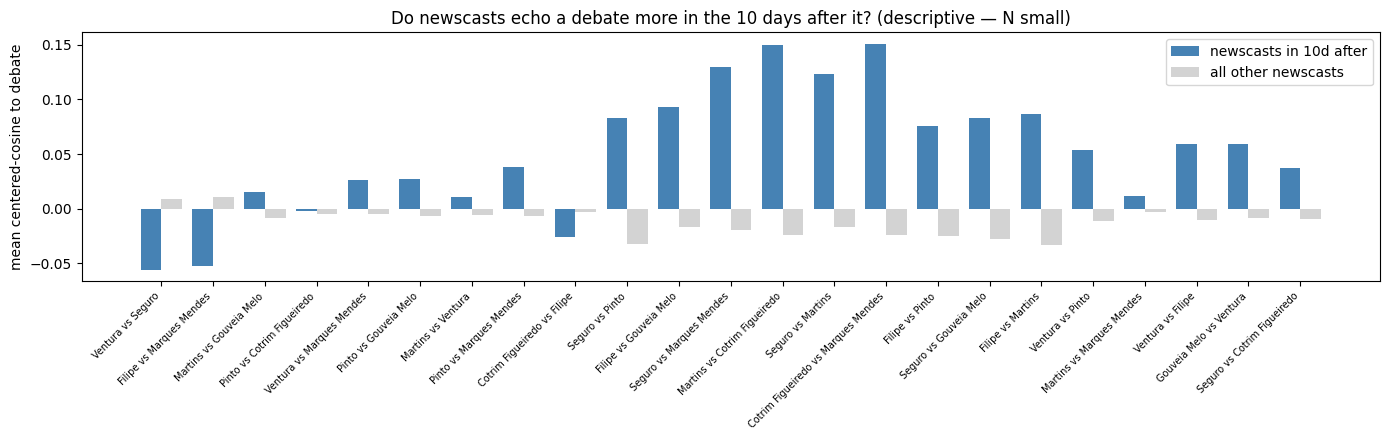

In [22]:
# Temporal echo: do newscasts in the 10 days AFTER a debate resemble it more than the rest?
WIN = 10
def newscasts_after(d0, win): return items_emb['date'].apply(lambda d: 0 < (d - d0).days <= win)
_er = []
for j, deb in debates.iterrows():
    mask = newscasts_after(deb['date'], WIN)
    if mask.sum() == 0: continue
    parts = {deb['candA'], deb['candB']}
    air = items_emb[mask & items_emb['cands'].apply(lambda s: bool(s & parts))]['duration_s'].sum() / 60
    _er.append(dict(debate=f"{deb['candA']} vs {deb['candB']}", date=deb['date'], n_news=int(mask.sum()),
                    sim_in_window=round(float(Smat[mask.values, j].mean()), 3),
                    sim_baseline=round(float(Smat[~mask.values, j].mean()), 3),
                    participant_min=round(air, 1)))
echo = pd.DataFrame(_er).sort_values('date').reset_index(drop=True)
print(f'{len(echo)}/{len(debates)} debates have >=1 newscast within {WIN} days after '
      f'(debates run only to Dec 21, so the January newscasts have no following debate).')
display(echo)
fig, ax = plt.subplots(figsize=(14, 4.5)); x = np.arange(len(echo))
ax.bar(x - .2, echo['sim_in_window'], .4, label=f'newscasts in {WIN}d after', color='steelblue')
ax.bar(x + .2, echo['sim_baseline'], .4, label='all other newscasts', color='lightgray')
ax.set_xticks(x); ax.set_xticklabels(echo['debate'].str.replace('_', ' '), rotation=45, ha='right', fontsize=7)
ax.set_ylabel('mean centered-cosine to debate'); ax.legend()
ax.set_title(f'Do newscasts echo a debate more in the {WIN} days after it? (descriptive — N small)')
plt.tight_layout(); plt.show()

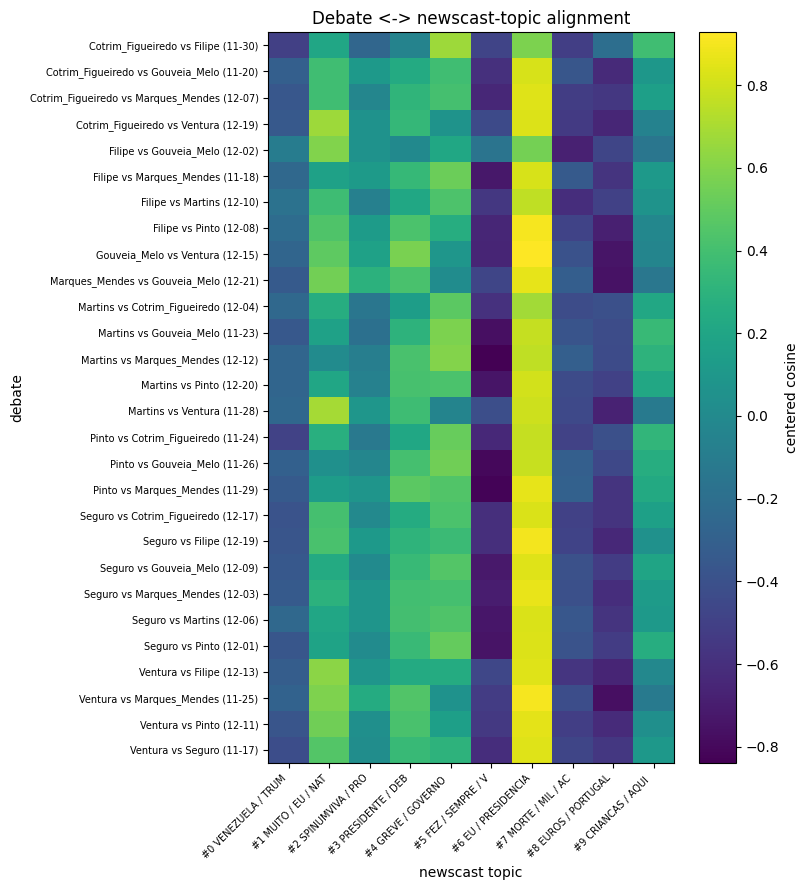

In [23]:
# Debate <-> newscast-topic alignment (centered cosine of each debate to each newscast-topic centroid)
_tc = allc.set_index(['video', 'item_id'])['topic_cluster']
ie_topic = np.array([_tc.get((r.video, r.item_id), -1) for r in items_emb.itertuples()])
topics = sorted(t for t in set(ie_topic) if t >= 0)
cent = np.vstack([NBc[ie_topic == t].mean(0) for t in topics])
_lab2 = {t: allc[allc.topic_cluster == t]['topic_label'].iloc[0] for t in topics}
H = cosine_similarity(DBc, cent)
ylabels = (debates['candA'] + ' vs ' + debates['candB'] + ' (' + debates['date'].astype(str).str[5:] + ')').tolist()
fig, ax = plt.subplots(figsize=(max(8, .7 * len(topics)), 9))
im = ax.imshow(H, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(topics))); ax.set_xticklabels([f'#{t} {_lab2[t][:16]}' for t in topics], rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=7)
fig.colorbar(im, ax=ax, label='centered cosine')
ax.set_title('Debate <-> newscast-topic alignment'); ax.set_xlabel('newscast topic'); ax.set_ylabel('debate')
plt.tight_layout(); plt.show()

## Can we predict poll evolution from coverage?

*Would you be able to predict the poll evolution?* We build a (poll-transition × candidate) panel whose feature is each candidate's newscast **mention-minutes in the days before** the poll, plus their previous poll level and party, and try to predict the **change** in their poll share. **This is exploratory only:** there are just 12 poll transitions × 8 candidates, several polling houses, and only 8 newscast dates — far too little to forecast. We report results *relative to a "polls persist" baseline* and claim no causality.

In [24]:
# Panel: per poll transition and candidate -> change in poll %, with a preceding-coverage feature
party = pd.read_pickle(f'{FEATURES_DIR}/candidate_party.pkl').set_index('Candidate')['Party'].to_dict()
WIN_D = 14   # mention-minutes summed over newscasts in the WIN_D days before each poll
def coverage_before(cand, d0, win):
    m = mentions_ts[(mentions_ts.candidate == cand) & mentions_ts.date.apply(lambda d: 0 <= (d0 - d).days < win)]
    return m['minutes'].sum()
_pr = []
for i in range(1, len(polls)):
    d0 = polls.loc[i, 'date_d']
    for c in CANDS:
        prev, cur = float(polls.loc[i - 1, c]), float(polls.loc[i, c])
        _pr.append(dict(poll_i=i, date=d0, candidate=c, party=party.get(c, '?'),
                        prev_level=prev, change=cur - prev, coverage_min=coverage_before(c, d0, WIN_D)))
panel = pd.DataFrame(_pr); nz = int((panel.coverage_min > 0).sum())
print(f'panel = {len(panel)} (poll-transition, candidate) rows; '
      f'{nz} ({nz / len(panel) * 100:.0f}%) have non-zero coverage in the preceding {WIN_D} days. N is tiny.')
display(panel.head(8))

panel = 96 (poll-transition, candidate) rows; 53 (55%) have non-zero coverage in the preceding 14 days. N is tiny.


,poll_i,date,candidate,party,prev_level,change,coverage_min
0,1,2025-10-30,Gouveia_Melo,Independent,26.9,-11.5,0.0
1,1,2025-10-30,Marques_Mendes,PSD+CDS,20.3,-3.7,0.0
2,1,2025-10-30,Seguro,PS,18.4,-6.1,0.0
3,1,2025-10-30,Ventura,CH,13.9,1.9,0.0
4,1,2025-10-30,Cotrim_Figueiredo,IL,9.1,-0.7,0.0
5,1,2025-10-30,Filipe,CDU,2.5,2.1,0.0
6,1,2025-10-30,Martins,BE,1.9,5.2,0.0
7,1,2025-10-30,Pinto,L,0.0,0.0,0.0


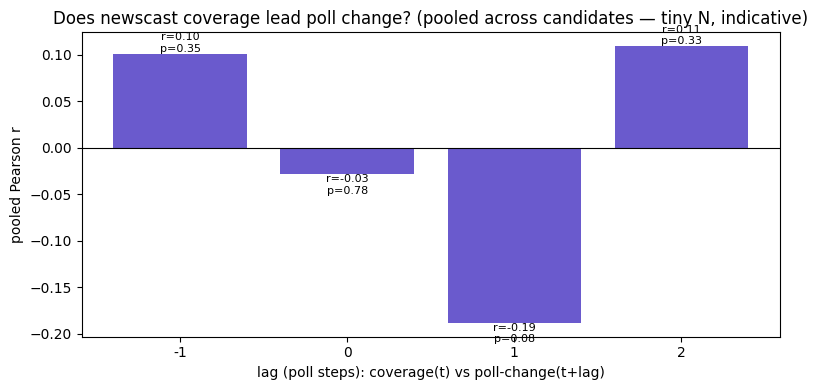

In [25]:
# Lagged cross-correlation (pooled across candidates): does coverage lead the poll change?
from scipy.stats import pearsonr
def lag_corr(lag):
    xs, ys = [], []
    for c in CANDS:
        g = panel[panel.candidate == c].sort_values('poll_i')
        cov, chg = g['coverage_min'].values, g['change'].values
        x, y = (cov[:len(cov) - lag], chg[lag:]) if lag >= 0 else (cov[-lag:], chg[:len(chg) + lag])
        xs += list(x); ys += list(y)
    xs, ys = np.array(xs), np.array(ys)
    if len(xs) < 4 or np.std(xs) < 1e-9: return np.nan, np.nan
    return pearsonr(xs, ys)
lags = [-1, 0, 1, 2]; res = [lag_corr(l) for l in lags]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(l) for l in lags], [r for r, _ in res], color='slateblue')
for kk, (r, pv) in enumerate(res):
    if not np.isnan(r): ax.text(kk, r, f'r={r:.2f}\np={pv:.2f}', ha='center', va='bottom' if r >= 0 else 'top', fontsize=8)
ax.axhline(0, color='k', lw=.8); ax.set_ylabel('pooled Pearson r')
ax.set_xlabel('lag (poll steps): coverage(t) vs poll-change(t+lag)')
ax.set_title('Does newscast coverage lead poll change? (pooled across candidates — tiny N, indicative)')
plt.tight_layout(); plt.show()

persistence baseline  : MAE = 2.84 pp (predicts no change)
ridge (leave-one-out) : MAE = 2.46 pp | direction correct 62% | R2 = 0.26
Verdict: coverage + prior level give a small edge over persistence, but with 12 poll steps x 8 candidates this is indicative only - not a forecast.


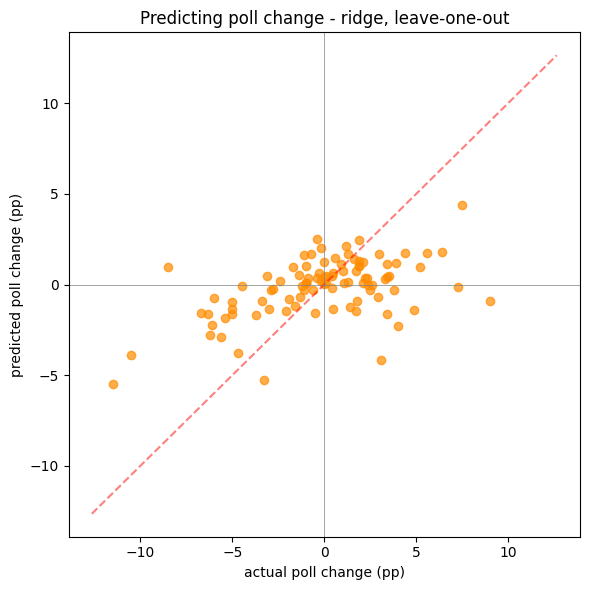

In [26]:
# Honest predictive check: ridge (leave-one-out) vs a "polls persist" baseline
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
d = panel.dropna(subset=['change']).reset_index(drop=True)
X = pd.get_dummies(d[['coverage_min', 'prev_level', 'party']], columns=['party']).astype(float).values
y = d['change'].values
pred = np.zeros(len(y))
for tr, te in LeaveOneOut().split(X):
    sc = StandardScaler().fit(X[tr])
    pred[te] = Ridge(alpha=5.0).fit(sc.transform(X[tr]), y[tr]).predict(sc.transform(X[te]))
base_mae = np.mean(np.abs(y))                       # persistence baseline: predicted change = 0
mae = np.mean(np.abs(pred - y)); dir_acc = np.mean(np.sign(pred) == np.sign(y))
r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
print(f'persistence baseline  : MAE = {base_mae:.2f} pp (predicts no change)')
print(f'ridge (leave-one-out) : MAE = {mae:.2f} pp | direction correct {dir_acc * 100:.0f}% | R2 = {r2:.2f}')
print('Verdict:', 'coverage + prior level give a small edge over persistence,' if mae < base_mae
      else 'coverage does NOT beat persistence,',
      'but with 12 poll steps x 8 candidates this is indicative only - not a forecast.')
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, pred, c='darkorange', alpha=.7); lim = max(np.abs(y).max(), np.abs(pred).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', alpha=.5); ax.axhline(0, color='grey', lw=.5); ax.axvline(0, color='grey', lw=.5)
ax.set_xlabel('actual poll change (pp)'); ax.set_ylabel('predicted poll change (pp)')
ax.set_title('Predicting poll change - ridge, leave-one-out'); plt.tight_layout(); plt.show()